# South Australia Electricity — Classical and Statistical Forecasting Baselines

## Role
This notebook establishes the transparent, non-neural benchmark floor for South
Australia electricity demand — ten deterministic, classical, and statistical
forecasting systems spanning three genuinely different update disciplines — against
which the supervised LSTM (`12_Electricity_LSTM.ipynb`) and zero-shot foundation models
(`13_Electricity_Foundation_Models.ipynb`) are later evaluated.

## Inputs
- The canonical South Australia half-hourly demand series and frozen Development /
  Validation / Pre-test / Test partitions (reconstructed once here from
  `data/electricity/australian_electricity_demand_dataset.tsf`).
- Saved Protocol A forecast artifacts (`results/electricity/protocol_a_*_forecast.csv`
  / `protocol_a_baseline_forecasts.csv`).
- Saved Protocol B forecast artifacts (`results/electricity/protocol_b_*_forecast.csv`
  / `protocol_b_baseline_forecasts.csv`, `protocol_b_horizon_metrics.csv`).
- Validation-selection evidence (`results/electricity/classical_model_selection.json`).

## Outputs
Individual classical-model evidence (method, configuration, protocol-specific
performance, forecast/horizon behaviour, residual diagnostics), a Protocol A comparison,
a Protocol B comparison, cross-model horizon-specific evidence, consolidated residual
diagnostics, and protocol/update-discipline interpretation. By default this notebook
does not write to any file; it only writes candidate forecast CSVs — to a staging
directory, never to the authoritative `results/electricity/` files — if a person
explicitly sets `RUN_FITTING = True` (Section 2).

## Depends On
`10_Electricity_EDA.ipynb`

## Authoritative Status
`AUTHORITATIVE ELECTRICITY CLASSICAL / STATISTICAL BENCHMARK` — supersedes
`11_Electricity_Baselines.ipynb`, `11b_Electricity_Statistical_Model.ipynb`, and
`11c_Electricity_Classical_Models.ipynb` (no longer present on disk) as the single
reference for these ten models.

## What This Notebook Does Not Do
This notebook does NOT:
- evaluate the LSTM (`12_Electricity_LSTM.ipynb`) or foundation models
  (`13_Electricity_Foundation_Models.ipynb`)
- compute Trust Scores or trustworthiness synthesis (`17_Electricity_Trustworthiness.ipynb`)
- perform statistical-significance testing (`18_Electricity_Statistical_Significance.ipynb`)
- perform any cross-domain comparison
- perform the consolidated forecast-artifact/evidence-integrity audit — that lives in
  `14_Electricity_Model_Validation_Audit.ipynb`

## 1. Objective and Research Questions

> How competitive are transparent deterministic, classical, and statistical forecasting
> systems for South Australia electricity demand when evaluated under two distinct
> operational forecasting protocols?

### Q1 — Protocol A
> Under next-step half-hour forecasting, which transparent baseline or statistical model
> establishes the strongest benchmark floor?

### Q2 — Protocol B
> Under true 48-step day-ahead forecasting, which models preserve accuracy across the
> full horizon, and how does the ranking differ from Protocol A?

### Q3 — Methodological
> How strongly do model-update discipline, seasonal structure, and forecast horizon
> influence apparent model quality?

These questions matter because later neural (`12_Electricity_LSTM.ipynb`) and
foundation-model (`13_Electricity_Foundation_Models.ipynb`) claims must be judged against
a serious and fairly evaluated classical floor, under the same two protocols. Protocol A
and Protocol B are evaluated and reported **separately** throughout this notebook and are
never combined into one ranking (Sections 3.2-3.3).

## 2. Setup

Normal execution (`RUN_SELECTION = False`, `RUN_FITTING = False`) is fully
artifact-driven: every hyperparameter and forecast vector below is loaded from an
already-saved artifact rather than recomputed. Setting either flag to `True` optionally
reruns validation-only selection or full model refitting from scratch (20-30 minutes);
neither is required to reproduce any output in this notebook.

In [1]:
from pathlib import Path
import sys, time, warnings, json
from ast import literal_eval
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
DATA = ROOT / "data/electricity/australian_electricity_demand_dataset.tsf"
RESULTS = ROOT / "results/electricity"
STAGING = RESULTS / "staging"  # RUN_FITTING candidate output only; never the authoritative directory
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.metrics import mae, rmse, mape, smape
from src.electricity_classical_models import (
    SCALE_MASE_48, FIT_WINDOW, forecast_frames, load_electricity_partitions, mase48,
    periodic_forecasts, select_periodic_cadence, select_state_specification,
    state_model_forecasts, training_seasonality,
)

selection_json = json.loads((RESULTS / "classical_model_selection.json").read_text(encoding="utf-8"))
model_run_log = []  # one row per model, appended at the point each model's configuration is derived

E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


### 2.1 Shared Evaluation and Loading Helpers

`parse_order_tuple` replaces `eval()` for turning a stored `"(2, 1, 0)"`-style
specification string back into a tuple, with shape/type validation.
`load_state_model_selection` and `load_periodic_model_selection` derive a selected
hyperparameter *programmatically* from the validation-evidence table already saved in
`classical_model_selection.json` (sort by `Validation_MASE_48`, take the first row) rather
than trusting a separately stored "selected value" field — the artifact's own recorded
choice is then checked for self-consistency against that independent derivation.
`load_protocol_a_forecast`/`load_protocol_b_forecast` centralize the repeated
read-CSV-and-verify-timestamp-alignment pattern used by every one of the ten models.
`save_candidate_forecast` is the **only** `to_csv` call site in this notebook: it is only
reachable when `RUN_FITTING=True`, and it never writes outside `STAGING`.

In [2]:
def metric_row(actual, pred, scale):
    return {"MAE": mae(actual, pred), "RMSE": rmse(actual, pred), "MAPE": mape(actual, pred),
            "sMAPE": smape(actual, pred), "MASE_48": mae(actual, pred) / scale}

def protocol_metric_table(actual, pred_a, pred_b, model, scale):
    return pd.DataFrame([
        {"Protocol": "A", "Model": model, **metric_row(actual, pred_a, scale)},
        {"Protocol": "B", "Model": model, **metric_row(actual, pred_b, scale)},
    ])

# Replaces eval(): turns a stored "(2, 1, 0)"-style specification string back into a
# validated tuple. Used for every ARIMA/SARIMA-order-shaped value loaded from evidence.
def parse_order_tuple(value):
    if isinstance(value, tuple):
        return value
    parsed = literal_eval(str(value))
    if not (isinstance(parsed, tuple) and len(parsed) in (3, 4) and all(isinstance(v, int) for v in parsed)):
        raise ValueError(f"Invalid ARIMA/SARIMA order specification: {value!r}")
    return parsed

# Derives a sequential state-update model's selected order from its saved
# validation-evidence table (classical_model_selection.json) by sorting on
# Validation_MASE_48 and taking the first row -- independent of the artifact's own
# separately recorded "Specification" field, which is then checked for consistency.
def load_state_model_selection(model_key):
    payload = selection_json["Models"][model_key]
    table = (
        pd.DataFrame(payload["Selection"])
        .assign(Specification=lambda d: d.Specification.map(parse_order_tuple))
        .sort_values("Validation_MASE_48").reset_index(drop=True)
    )
    order = table.iloc[0].Specification
    assert order == parse_order_tuple(payload["Specification"]), (
        f"{model_key}: order derived from the selection table disagrees with the artifact's own recorded choice"
    )
    return order, table

# Same derivation pattern as load_state_model_selection, for periodic-refit cadence.
def load_periodic_model_selection(model_key):
    payload = selection_json["Models"][model_key]
    table = pd.DataFrame(payload["Selection"]).sort_values("Validation_MASE_48").reset_index(drop=True)
    cadence = int(table.iloc[0].Cadence)
    assert cadence == payload["Cadence_Half_Hours"], (
        f"{model_key}: cadence derived from the selection table disagrees with the artifact's own recorded choice"
    )
    return cadence, table

def load_protocol_a_forecast(filename, timestamp_index):
    df = pd.read_csv(RESULTS / filename, parse_dates=["Timestamp"])
    if not df.Timestamp.equals(pd.Series(timestamp_index, name="Timestamp")):
        raise ValueError(f"{filename}: Timestamp column does not match the frozen test partition")
    return df

def load_protocol_b_forecast(filename, timestamp_index):
    df = pd.read_csv(RESULTS / filename, parse_dates=["Origin", "Timestamp"])
    if not df.Timestamp.equals(pd.Series(timestamp_index, name="Timestamp")):
        raise ValueError(f"{filename}: Timestamp column does not match the frozen test partition")
    return df

# The only to_csv() call site in this notebook. Only reachable when RUN_FITTING=True;
# always writes inside STAGING, never to the authoritative results/electricity/ files.
def save_candidate_forecast(df, filename):
    STAGING.mkdir(parents=True, exist_ok=True)
    path = STAGING / filename
    df.to_csv(path, index=False, date_format="%Y-%m-%d %H:%M:%S")
    return path

def load_or_fit_state_model(model_key, order, csv_stub, run_fitting):
    if run_fitting:
        t0 = time.perf_counter()
        pred_a, pred_b = state_model_forecasts(parts, model_key, order)
        runtime = time.perf_counter() - t0
        pa, pb = forecast_frames(test, pred_a, pred_b, model_key)
        save_candidate_forecast(pa, f"protocol_a_{csv_stub}_forecast.csv")
        save_candidate_forecast(pb, f"protocol_b_{csv_stub}_forecast.csv")
        return pa, pb, runtime
    pa = load_protocol_a_forecast(f"protocol_a_{csv_stub}_forecast.csv", test.index)
    pb = load_protocol_b_forecast(f"protocol_b_{csv_stub}_forecast.csv", test.index)
    return pa, pb, None

def load_or_fit_periodic_model(model_key, cadence, csv_stub, run_fitting):
    if run_fitting:
        t0 = time.perf_counter()
        pred_a, pred_b = periodic_forecasts(parts.pretest, parts.test, model_key, cadence)
        runtime = time.perf_counter() - t0
        pa, pb = forecast_frames(test, pred_a, pred_b, model_key)
        save_candidate_forecast(pa, f"protocol_a_{csv_stub}_forecast.csv")
        save_candidate_forecast(pb, f"protocol_b_{csv_stub}_forecast.csv")
        return pa, pb, runtime
    pa = load_protocol_a_forecast(f"protocol_a_{csv_stub}_forecast.csv", test.index)
    pb = load_protocol_b_forecast(f"protocol_b_{csv_stub}_forecast.csv", test.index)
    return pa, pb, None

def plot_protocol_ab_window(test, pred_a, pred_b, model_label, color, window=slice(0, 336)):
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    titles = ["Protocol A: rolling one-step (first 7 days)", "Protocol B: 48-step day-ahead (first 7 days)"]
    for ax, pred, title in zip(axs, [pred_a, pred_b], titles):
        ax.plot(test.index[window], test.iloc[window], label="Actual", color="#333333", lw=1.2)
        ax.plot(test.index[window], np.asarray(pred)[window], label=model_label, color=color, lw=1.2)
        ax.set(title=title, xlabel="Timestamp", ylabel="Demand")
        ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=30)
    fig.suptitle(f"{model_label}: actual vs forecast, representative 7-day window")
    fig.tight_layout()
    return fig

# Lightweight per-model residual diagnostic derived only from already-loaded frozen
# forecasts -- no refitting. e_t = y_t - y_hat_t (Actual minus Forecast).
def residual_summary(actual, pred, model, protocol):
    resid = np.asarray(actual) - np.asarray(pred)
    return {"Model": model, "Protocol": protocol, "Mean Residual": resid.mean(), "Std": resid.std(),
            "Median": np.median(resid), "95th Abs Error": np.percentile(np.abs(resid), 95), "Max Abs Error": np.abs(resid).max()}

def horizon_metrics_from_pb(pb_frame, actual, model, scale):
    rows = []
    for h, g in pb_frame.groupby("Horizon"):
        rows.append({"Model": model, "Horizon": int(h), **metric_row(actual.loc[g.Timestamp].to_numpy(), g[model].to_numpy(), scale)})
    return pd.DataFrame(rows)

### 2.2 Frozen Research Configuration

Fixed methodological constants and search-space definitions, centralized once rather
than scattered as inline literals through the model sections below. These are not
experimental results — they are the same seasonal periods, forecast horizon, and
validation grids the original 11/11b/11c notebooks used.

In [3]:
SEASONAL_PERIODS = {"daily": 48, "weekly": 336}
FORECAST_HORIZON = 48
MOVING_AVERAGE_CANDIDATES = (48, 96, 336)
DHR_SEARCH_SPACE = {
    "daily_k": (2, 4, 6),
    "weekly_k": (2, 4, 6),
    "arima_orders": ((1, 0, 0), (2, 0, 0), (1, 0, 1)),
}

# Regression-guard expectations only, checked AFTER each hyperparameter is derived from
# its validation evidence below (Sections 4.1, 5.2, 6.1, 7.1, 8.1, 9.1, 10.1) -- these
# values do not drive selection; they document what selection is expected to reproduce.
EXPECTED_SELECTED_CONFIG = {
    "moving_average_window": 48,
    "dhr_arima": {"daily_k": 2, "weekly_k": 6, "arima_order": (2, 0, 0)},
    "arima_order": (2, 1, 0),
    "sarima_order": (0, 1, 0, 48),
    "prophet_cadence_half_hours": 672,
    "ses_cadence_half_hours": 48,
    "holt_winters_cadence_half_hours": 672,
}

display(pd.Series(SEASONAL_PERIODS, name="Half-hours per period").to_frame())
display(pd.DataFrame([{"Model": k, **(v if isinstance(v, dict) else {"Value": v})} for k, v in EXPECTED_SELECTED_CONFIG.items()]))

,Half-hours per period
daily,48
weekly,336


,Model,Value,daily_k,weekly_k,arima_order
0,moving_average_window,48,NaN,NaN,NaN
1,dhr_arima,NaN,2.0,6.0,"(2, 0, 0)"
2,arima_order,"(2, 1, 0)",NaN,NaN,NaN
3,sarima_order,"(0, 1, 0, 48)",NaN,NaN,NaN
4,prophet_cadence_half_hours,672,NaN,NaN,NaN
5,ses_cadence_half_hours,48,NaN,NaN,NaN
6,holt_winters_cadence_half_hours,672,NaN,NaN,NaN


### 2.3 DHR-ARIMA Selection Evidence Provenance

Five of the seven hyperparameter selections in this notebook (ARIMA, SARIMA, Prophet,
Simple Exponential Smoothing, Holt-Winters) are loaded live from a machine-readable
artifact, `results/electricity/classical_model_selection.json`, produced by
`src/generate_electricity_classical_artifacts.py`. The moving-average window (Section
4.4) is cheap enough to recompute live on every run from the frozen validation series,
regardless of `RUN_SELECTION`.

DHR-ARIMA (Section 5) is the one remaining exception. Its 27-row Fourier/ARIMA-order
validation grid was never persisted as a standalone machine-readable artifact by the
original workflow, and recomputing it costs roughly 8 minutes — too expensive to run on
every default execution. The selected configuration (`daily_K=2, weekly_K=6,
order=(2,0,0)`) is therefore retained as a **frozen research decision** in
`EXPECTED_SELECTED_CONFIG` (Section 2.2) — methodology, not a re-derived test-set result —
rather than as a redisplayed selection grid. `RUN_SELECTION=True` reproduces the grid, the
fitted coefficients, and the residual diagnostic (Section 5.6) dynamically from preserved
development/validation data; this is a real, remaining reproducibility limitation of the
original workflow, reported as such rather than papered over with a transcribed literal.

### Execution Policy

```
RUN_SELECTION = False   # if True, reruns validation-only hyperparameter selection (~20+ minutes total)
RUN_FITTING   = False   # if True, refits all ten models and regenerates forecast CSVs (~25+ minutes total)
```

By default (both `False`), this notebook loads the already-saved, validation-selected
hyperparameters and the already-saved forecast CSVs. Setting either flag to `True` reruns
that work from scratch and takes 25-30 minutes; this should only be done if a genuine bug
is suspected in the selection or fitting logic itself. Even with `RUN_FITTING=True`,
regenerated forecasts are written only to `results/electricity/staging/`, never to the
authoritative `results/electricity/` files.

In [4]:
RUN_SELECTION = False   # if True, reruns validation-only hyperparameter selection (~20+ minutes total)
RUN_FITTING = False     # if True, refits all ten models and regenerates forecast CSVs (~25+ minutes total)
display(pd.Series({"RUN_SELECTION": RUN_SELECTION, "RUN_FITTING": RUN_FITTING}, name="Execution policy").to_frame())

,Execution policy
RUN_SELECTION,False
RUN_FITTING,False


# 3. Shared Experimental Design

Before any model is introduced, this section fixes the data, the two evaluation
protocols, the metrics, the seasonal evidence that motivates the model roster, and the
three update disciplines that distinguish how each forecasting system is allowed to use
information during the test period.

## 3.1 Data and Frozen Partitions

One consolidated load + partition block (`T4`/SA reconstruction, Development / Validation
/ Pre-test / Test).

In [5]:
parts = load_electricity_partitions(ROOT)
full, dev, validation, pretest, test = parts.full, parts.development, parts.validation, parts.pretest, parts.test
values = full.to_numpy()
positions = pd.Series(np.arange(len(full)), index=full.index)

dev_scale = float(np.mean(np.abs(dev.to_numpy()[48:] - dev.to_numpy()[:-48])))
final_scale = float(np.mean(np.abs(pretest.to_numpy()[48:] - pretest.to_numpy()[:-48])))
assert np.isclose(final_scale, SCALE_MASE_48, atol=1e-9)
assert np.isclose(final_scale, 117.057971280678, atol=1e-9)

partition_table = pd.DataFrame({
    "Partition": ["Development", "Validation", "Pre-test", "Test"],
    "Start": [z.index[0] for z in [dev, validation, pretest, test]],
    "End": [z.index[-1] for z in [dev, validation, pretest, test]],
    "Observations": [len(z) for z in [dev, validation, pretest, test]],
    "Role": ["Hyperparameter/order selection input", "Model/configuration selection",
             "Final pre-test history (Development + Validation)", "Frozen evaluation (never used for selection)"],
})
display(partition_table)
display(pd.Series({"Development_MASE_48_denominator": dev_scale, "Final_pretest_MASE_48_denominator": final_scale}, name="Value").to_frame())

,Partition,Start,End,Observations,Role
0,Development,2002-01-01,2011-06-23 23:30:00,166128,Hyperparameter/order selection input
1,Validation,2011-06-24,2012-07-12 23:30:00,18480,Model/configuration selection
2,Pre-test,2002-01-01,2012-07-12 23:30:00,184608,Final pre-test history (Development + Validation)
3,Test,2012-07-13,2015-03-01 23:30:00,46176,Frozen evaluation (never used for selection)


,Value
Development_MASE_48_denominator,117.734228
Final_pretest_MASE_48_denominator,117.057971


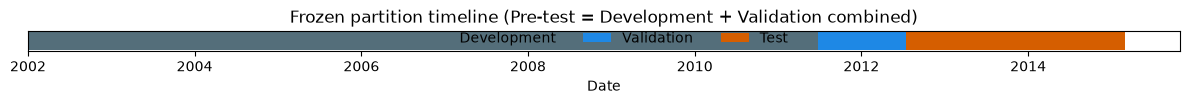

In [6]:
fig, ax = plt.subplots(figsize=(12, 1.6))
colors = {"Development": "#546e7a", "Validation": "#1e88e5", "Pre-test (Dev+Val, shown once)": "#90a4ae", "Test": "#D55E00"}
segments = [("Development", dev.index[0], dev.index[-1]), ("Validation", validation.index[0], validation.index[-1]),
            ("Test", test.index[0], test.index[-1])]
for i, (label, start, end) in enumerate(segments):
    ax.barh(0, (end - start), left=start, height=0.5, color=colors[label], label=label)
ax.set_yticks([]); ax.set(title="Frozen partition timeline (Pre-test = Development + Validation combined)", xlabel="Date")
ax.legend(loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.6))
plt.tight_layout(); plt.show()

T4/SA reconstruction and the frozen (166128, 18480, 184608, 46176) partition shapes are
verified internally by `load_electricity_partitions` (it raises on mismatch); the
`assert` statements above independently re-verify the frozen MASE-48 denominator. These
boundaries are read-only here — they are not redefined, and no test observation is used
for any selection decision anywhere in this notebook.

## 3.2 Protocol A — Next-Step Half-Hour Forecasting

At each origin, a model forecasts exactly one half-hour ahead using only information
available strictly before that origin. For pure-formula and sequential state-update
models, the actual value observed at each origin becomes available before the *next*
origin's forecast — a genuine rolling one-step design. Periodic-refit models (Section 3.6)
instead hold one fixed fit between refits, so within a refit window their Protocol A
output is not a fresh one-step re-estimate, only a fresh evaluation point.

In [7]:
protocol_a_table = pd.DataFrame([{
    "Property": "Horizon", "Protocol A": "1 half-hour (30 minutes)",
}, {
    "Property": "Frequency", "Protocol A": "Every half-hour of the test period",
}, {
    "Property": "Forecast unit", "Protocol A": "Point forecast of demand at t",
}, {
    "Property": "Test observations", "Protocol A": len(test),
}, {
    "Property": "Update after observation", "Protocol A": "Yes, for pure-formula and sequential state-update models (Section 3.6)",
}, {
    "Property": "Primary use", "Protocol A": "Short-horizon operational forecasting",
}])
display(protocol_a_table)

,Property,Protocol A
0,Horizon,1 half-hour (30 minutes)
1,Frequency,Every half-hour of the test period
2,Forecast unit,Point forecast of demand at t
3,Test observations,46176
4,Update after observation,"Yes, for pure-formula and sequential state-upd..."
5,Primary use,Short-horizon operational forecasting


## 3.3 Protocol B — True 48-Step Day-Ahead Forecasting

At each daily origin (962 origins, one per day of the 46,176-observation test period), a
model produces all 48 forecasts for that day at once, using only information available
strictly before the origin. No actual observed during that day is used to revise any of
the 48 forecasts inside the block — this is what makes Protocol B a genuine day-ahead
protocol rather than a relabelled one-step evaluation.

In [8]:
protocol_b_table = pd.DataFrame([{
    "Property": "Forecast horizon", "Protocol B": "48 half-hours",
}, {
    "Property": "Horizon duration", "Protocol B": "24 hours",
}, {
    "Property": "Within-block actual updates", "Protocol B": "No",
}, {
    "Property": "Evaluation", "Protocol B": "Point metrics + horizon-specific metrics (Section 13)",
}, {
    "Property": "Main difficulty", "Protocol B": "Error propagation / horizon degradation across the 48-step block",
}])
display(protocol_b_table)

,Property,Protocol B
0,Forecast horizon,48 half-hours
1,Horizon duration,24 hours
2,Within-block actual updates,No
3,Evaluation,Point metrics + horizon-specific metrics (Sect...
4,Main difficulty,Error propagation / horizon degradation across...


Protocol A and Protocol B are not two views of the same forecast — a model can rank very
differently under each (Section 15), because the two protocols pose genuinely different
forecasting problems with different information sets.

## 3.4 Evaluation Metrics

In [9]:
metric_definitions = pd.DataFrame([
    {"Metric": "MAE", "Purpose": "Absolute error magnitude", "Direction": "Lower better"},
    {"Metric": "RMSE", "Purpose": "Penalises large misses more than MAE", "Direction": "Lower better"},
    {"Metric": "MAPE", "Purpose": "Scale-relative percentage error", "Direction": "Lower better"},
    {"Metric": "sMAPE", "Purpose": "Symmetric percentage error (bounded, avoids MAPE's asymmetry)", "Direction": "Lower better"},
    {"Metric": "MASE-48", "Purpose": "Error relative to a lag-48 (daily) seasonal-naive scale", "Direction": "Lower better; <1 beats seasonal-naive scale"},
])
display(metric_definitions)
print(f"Frozen MASE-48 denominator (mean absolute lag-48 difference over the pre-test partition): {final_scale}")

,Metric,Purpose,Direction
0,MAE,Absolute error magnitude,Lower better
1,RMSE,Penalises large misses more than MAE,Lower better
2,MAPE,Scale-relative percentage error,Lower better
3,sMAPE,"Symmetric percentage error (bounded, avoids MA...",Lower better
4,MASE-48,Error relative to a lag-48 (daily) seasonal-na...,Lower better; <1 beats seasonal-naive scale


Frozen MASE-48 denominator (mean absolute lag-48 difference over the pre-test partition): 117.05797128067839


Lag 48 is one full day at half-hourly frequency (Section 3.6/Section 10 of
`10_Electricity_EDA.ipynb`) — MASE-48 expresses every model's absolute error relative to
how large a naive day-over-day change typically is, making it comparable across models and
protocols without depending on demand's absolute MW scale.

## 3.5 Seasonal Evidence Relevant to Benchmark Design

`10_Electricity_EDA.ipynb` owns the full exploratory seasonality analysis; this is a
concise benchmark-design confirmation, re-derived from **development data only** (no
validation, pre-test, or test observations) to rule out hindsight framing.

In [10]:
dev_seasonality = training_seasonality(dev)
seasonal_evidence = pd.DataFrame([
    {"Seasonal Scale": "Short persistence", "Lag": 1, "Evidence": "Very high ACF (10_Electricity_EDA.ipynb, Section 12)", "Benchmark/Model Implication": "Naive"},
    {"Seasonal Scale": "Daily", "Lag": 48, "Evidence": f"Development-only ACF = {dev_seasonality['Lag_48_ACF']:.4f}", "Benchmark/Model Implication": "Daily Seasonal Naive / SARIMA / Holt-Winters (period 48)"},
    {"Seasonal Scale": "Weekly", "Lag": 336, "Evidence": f"Development-only ACF = {dev_seasonality['Lag_336_ACF']:.4f}", "Benchmark/Model Implication": "Weekly Seasonal Naive / DHR (weekly Fourier terms) / Prophet"},
])
display(seasonal_evidence)

,Seasonal Scale,Lag,Evidence,Benchmark/Model Implication
0,Short persistence,1,"Very high ACF (10_Electricity_EDA.ipynb, Secti...",Naive
1,Daily,48,Development-only ACF = 0.8117,Daily Seasonal Naive / SARIMA / Holt-Winters (...
2,Weekly,336,Development-only ACF = 0.7195,Weekly Seasonal Naive / DHR (weekly Fourier te...


Both periods are confirmed strong on development data alone. A conventional seasonal
ARIMA with simultaneous periods 48 and 336 would create an unnecessarily large state
space over more than 166,000 development observations — SARIMAX's seasonal state space
scales with the seasonal period, so a seasonal order at period 336 (fit and then
sequentially `.extend()`-ed 962 times over the test set) is not viable at this data
volume, and Holt-Winters' `seasonal_periods` argument accepts only one period per model
instantiation. Consequently:

- **SARIMA** and **Holt-Winters** use a single seasonal period, **48 (daily)**. The
  weekly period (336) is *not* jointly modelled by either — a stated computational
  fallback, not a claim that weekly seasonality is unimportant (Section 17, Limitations).
- **Prophet** does *not* face this limitation: its own Fourier-term implementation
  supports `daily_seasonality=True, weekly_seasonality=True` simultaneously in a single
  fit — a genuine structural advantage over SARIMA/Holt-Winters at this data scale.
- **ARIMA** (non-seasonal) uses no seasonal period at all, serving as a plain-order
  baseline alongside the seasonal-aware comparators.
- **DHR-ARIMA** sidesteps the tradeoff entirely via deterministic Fourier regression for
  *both* seasonalities simultaneously, followed by a low-order non-seasonal ARIMA error
  process (Section 5.1). These model families do not have identical seasonal capacity —
  this asymmetry is a limitation of the comparison, not concealed (Section 17).

## 3.6 Forecast-System Update Disciplines

This is one of the most important Electricity-specific sections: the comparison below is
between complete forecasting *systems*, not model names alone. Update discipline is part
of the evaluated method.

In [11]:
update_discipline_table = pd.DataFrame([
    {"Update Discipline": "Pure Formula", "Models": "Naive, Daily Seasonal Naive, Weekly Seasonal Naive, Moving Average",
     "Behaviour": "Deterministic closed-form rule; no fitting, no state"},
    {"Update Discipline": "Sequential Fixed-Parameter State Update", "Models": "DHR-ARIMA, ARIMA, SARIMA",
     "Behaviour": "Parameters estimated once on pre-test data and then held fixed; only the observed-history state is extended (0 refits during test)"},
    {"Update Discipline": "Validation-Selected Periodic Refit", "Models": "Prophet, Simple Exponential Smoothing, Holt-Winters",
     "Behaviour": "Full model re-estimation on a validation-selected cadence; between refits, forecasts come from a single fixed fit"},
])
display(update_discipline_table)

,Update Discipline,Models,Behaviour
0,Pure Formula,"Naive, Daily Seasonal Naive, Weekly Seasonal N...","Deterministic closed-form rule; no fitting, no..."
1,Sequential Fixed-Parameter State Update,"DHR-ARIMA, ARIMA, SARIMA",Parameters estimated once on pre-test data and...
2,Validation-Selected Periodic Refit,"Prophet, Simple Exponential Smoothing, Holt-Wi...",Full model re-estimation on a validation-selec...


> The comparison is between complete forecasting systems, not model names alone. Update
> discipline is part of the evaluated method.

Section 15.3 revisits this table populated with each model's exact specification and
observed runtime once every model has been evaluated below.

# 4. Deterministic Baselines

These models are intentionally simple and transparent, pure closed-form formulas with no
fitting. They test whether the more complex systems in Sections 5-10 improve on obvious
temporal recurrence.

In [12]:
baseline_models = ["Naive", "Daily_Seasonal_Naive", "Weekly_Seasonal_Naive", "Moving_Average"]
pa_baseline = load_protocol_a_forecast("protocol_a_baseline_forecasts.csv", test.index)
pb_baseline = load_protocol_b_forecast("protocol_b_baseline_forecasts.csv", test.index)
hmetrics = pd.read_csv(RESULTS / "protocol_b_horizon_metrics.csv")

def baseline_protocol_a_row(model):
    return pd.DataFrame([{"Model": model, **metric_row(pa_baseline.Actual, pa_baseline[model], final_scale)}])

def baseline_protocol_b_row(model):
    return pd.DataFrame([{"Model": model, **metric_row(pb_baseline.Actual, pb_baseline[model], final_scale)}])

def baseline_horizon_profile(model, color):
    g = hmetrics[hmetrics.Model == model]
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
    axs[0].plot(g.Horizon, g.RMSE, color=color); axs[0].set(title=f"{model}: RMSE by horizon", xlabel="Horizon", ylabel="RMSE")
    axs[1].plot(g.Horizon, g.MASE_48, color=color); axs[1].set(title=f"{model}: MASE-48 by horizon", xlabel="Horizon", ylabel="MASE-48")
    for ax in axs:
        ax.grid(alpha=0.25)
    fig.tight_layout(); plt.show()

## 4.1 Naive Persistence

### Method

Protocol A: `y_hat[t] = y[t-1]` (the immediately prior half-hourly observation). Protocol
B: every half-hour of a day-ahead block repeats the single last actual observed before
that day's origin — `y_hat = repeat(y[origin-1], 48)`.

### Protocol A Performance

In [13]:
display(baseline_protocol_a_row("Naive"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Naive,42.271787,58.272152,3.465892,3.486887,0.361118


### Protocol A Visualisation

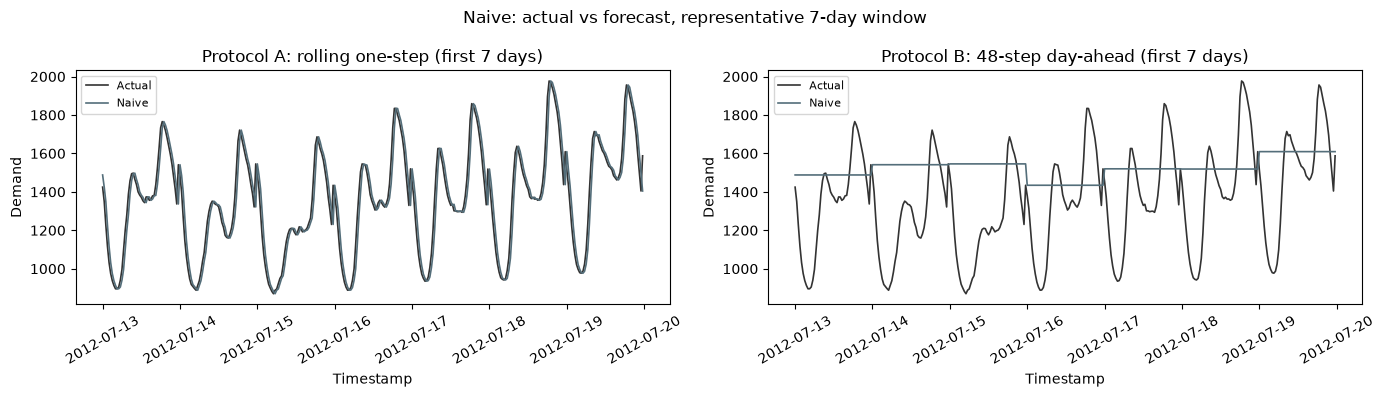

In [14]:
plot_protocol_ab_window(test, pa_baseline.Naive, pb_baseline.Naive, "Naive", "#546e7a")
plt.show()

### Protocol B Performance

In [15]:
display(baseline_protocol_b_row("Naive"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Naive,243.838179,301.681217,22.907776,19.738307,2.083055


### Protocol B Horizon Profile

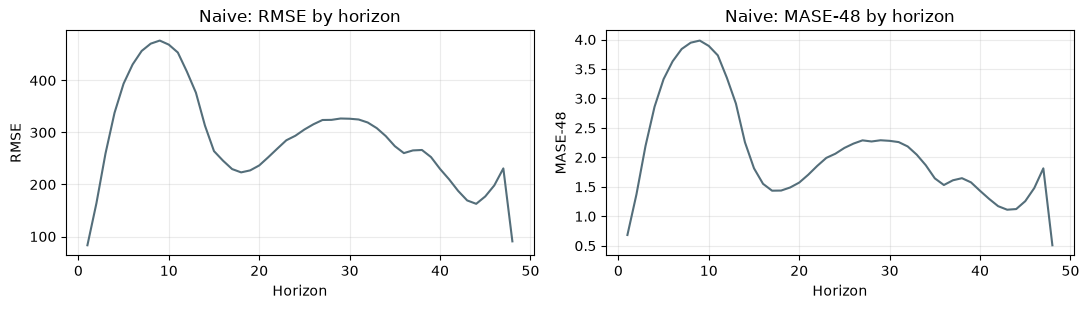

In [16]:
baseline_horizon_profile("Naive", "#546e7a")

### Interpretation

Naive achieves the best Protocol A MASE-48 among the four deterministic baselines
(Section 11.1) because half-hourly demand changes little from one 30-minute step to the
next. Under Protocol B it degrades sharply: it never observes an actual within its own
48-step block, so error grows with horizon distance from the last-known value (visible
above) rather than staying flat.

## 4.2 Daily Seasonal Naive

### Method

Protocol A: `y_hat[t] = y[t-48]` (repeats the demand from the same half-hour one day
earlier). Protocol B: the entire day-ahead block repeats the previous day's complete
48-slot shape. Lag 48 is one full day at half-hourly frequency (Section 3.5).

### Protocol A Performance

In [17]:
display(baseline_protocol_a_row("Daily_Seasonal_Naive"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Daily_Seasonal_Naive,129.41618,200.442098,10.64079,10.471882,1.105573


### Protocol A Visualisation

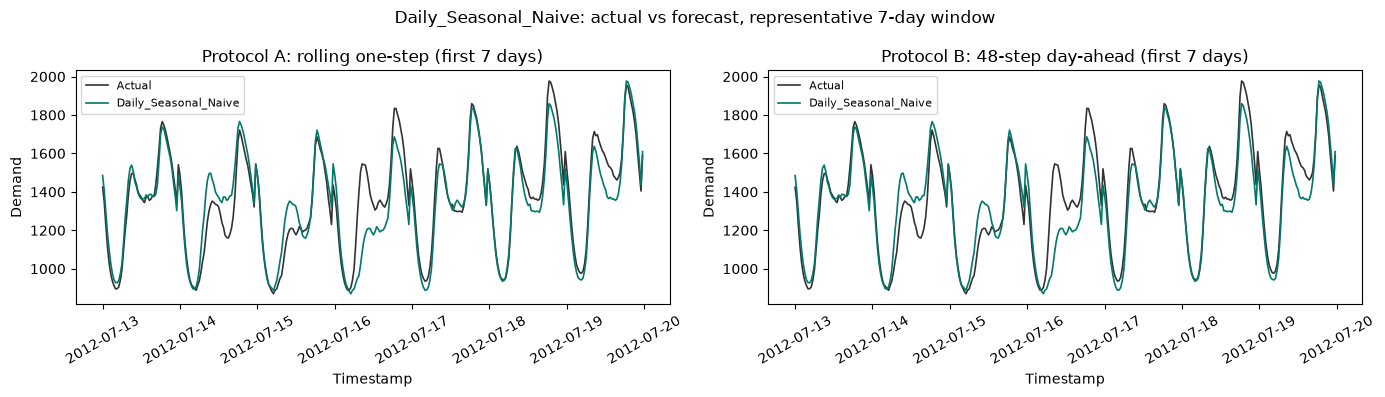

In [18]:
plot_protocol_ab_window(test, pa_baseline.Daily_Seasonal_Naive, pb_baseline.Daily_Seasonal_Naive, "Daily_Seasonal_Naive", "#00796b")
plt.show()

### Protocol B Performance

In [19]:
display(baseline_protocol_b_row("Daily_Seasonal_Naive"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Daily_Seasonal_Naive,129.41618,200.442098,10.64079,10.471882,1.105573


### Protocol B Horizon Profile

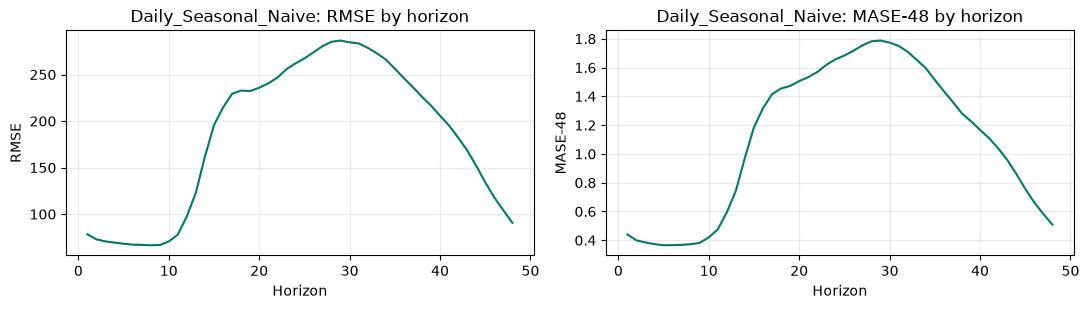

In [20]:
baseline_horizon_profile("Daily_Seasonal_Naive", "#00796b")

### Interpretation

This model is especially important under Protocol B: because it does not depend on how
recently an actual was observed, its day-ahead shape does not systematically decay across
the 48-step horizon the way Naive's does (Section 11.2) — day-ahead demand strongly
repeats the previous day's overall shape (Section 3.5).

## 4.3 Weekly Seasonal Naive

### Method

Protocol A: `y_hat[t] = y[t-336]` (repeats demand from the same half-hour one week
earlier). Protocol B: the day-ahead block repeats the same weekday's shape from one week
prior. Lag 336 is one full week at half-hourly frequency (Section 3.5).

### Protocol A Performance

In [21]:
display(baseline_protocol_a_row("Weekly_Seasonal_Naive"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.66229,1.308845


### Protocol A Visualisation

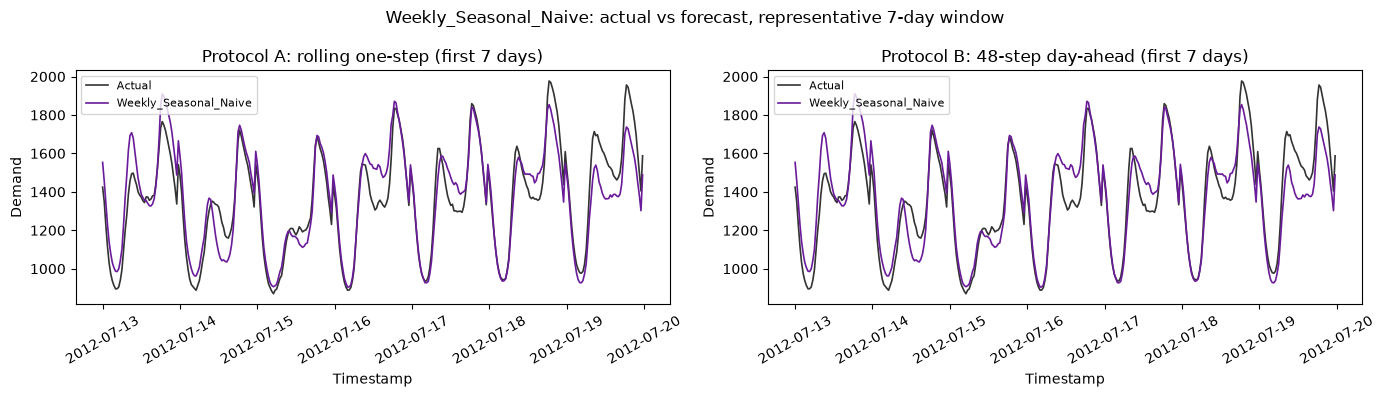

In [22]:
plot_protocol_ab_window(test, pa_baseline.Weekly_Seasonal_Naive, pb_baseline.Weekly_Seasonal_Naive, "Weekly_Seasonal_Naive", "#6a1b9a")
plt.show()

### Protocol B Performance

In [23]:
display(baseline_protocol_b_row("Weekly_Seasonal_Naive"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.66229,1.308845


### Protocol B Horizon Profile

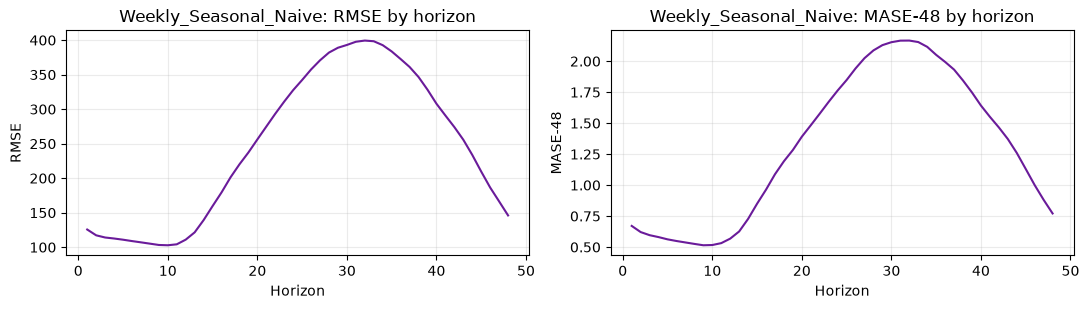

In [24]:
baseline_horizon_profile("Weekly_Seasonal_Naive", "#6a1b9a")

### Interpretation

Weekly Seasonal Naive is weaker than Daily Seasonal Naive under both protocols (Sections
11.1-11.2): a week-old observation is a noisier predictor of today's demand than a
day-old one, consistent with the development-only ACF evidence in Section 3.5 (lag-48
autocorrelation exceeds lag-336). It remains a genuinely different forecasting rule from
Daily Seasonal Naive, not a weaker copy of it — the two disagree on ordinary weekday-shape
changes across a week.

## 4.4 Moving Average

### Validation-Only Window Selection

The moving-average selection grid is a handful of rolling means over the validation
window — cheap enough to recompute deterministically from the frozen data on every run,
so it is **not** gated behind `RUN_SELECTION` and no historical transcript is kept for it.

In [25]:
val_rows = []
for w in MOVING_AVERAGE_CANDIDATES:
    pred = full.rolling(w).mean().shift(1).loc[validation.index]
    assert pred.notna().all()
    val_rows.append({"Window": w, **metric_row(validation, pred, dev_scale)})
ma_selection = pd.DataFrame(val_rows).sort_values("MASE_48").reset_index(drop=True)
display(ma_selection)

selected_window = int(ma_selection.iloc[0].Window)
assert selected_window == EXPECTED_SELECTED_CONFIG["moving_average_window"]
print(f"Selected moving-average window: {selected_window} half-hours ({selected_window / 48:.0f} day).")

model_run_log.extend([
    {"Model": m, "Discipline": "Pure formula", "Specification": spec, "Cadence_Days": None, "Refits_During_Test": 0, "Runtime_Seconds": None}
    for m, spec in [
        ("Naive", "y_hat[t] = y[t-1]"),
        ("Daily_Seasonal_Naive", "y_hat[t] = y[t-48]"),
        ("Weekly_Seasonal_Naive", "y_hat[t] = y[t-336]"),
        ("Moving_Average", f"Trailing mean, window={selected_window}"),
    ]
])

,Window,MAE,RMSE,MAPE,sMAPE,MASE_48
0,48,182.433952,229.910373,14.881769,14.209181,1.549540
1,96,197.175811,246.053874,16.061527,15.382465,1.674754
2,336,209.414697,261.137362,17.016459,16.301675,1.778707


Selected moving-average window: 48 half-hours (1 day).


### Protocol A Performance

In [26]:
display(baseline_protocol_a_row("Moving_Average"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Moving_Average,179.122226,227.658772,15.24338,14.67474,1.530201


### Protocol A Visualisation

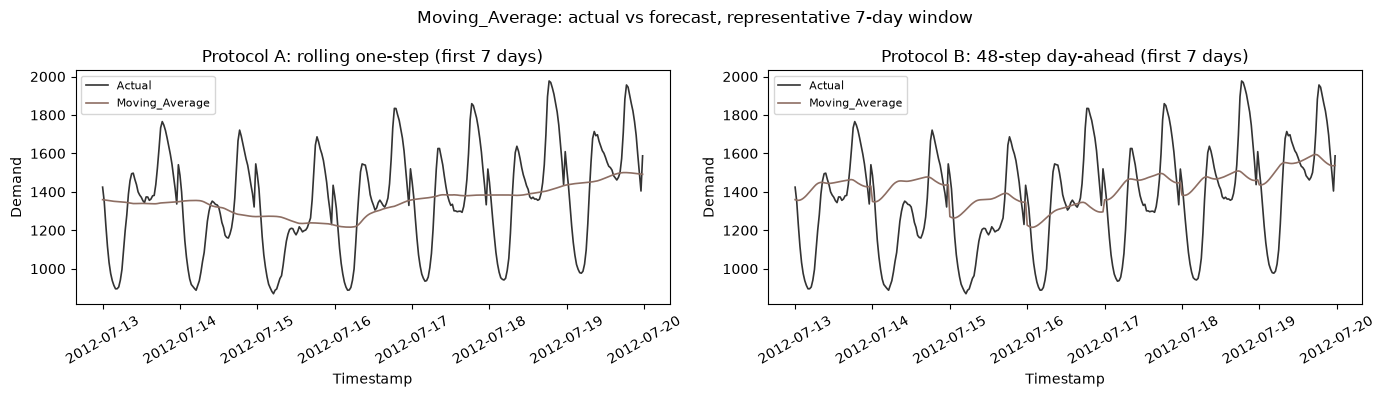

In [27]:
plot_protocol_ab_window(test, pa_baseline.Moving_Average, pb_baseline.Moving_Average, "Moving_Average", "#8d6e63")
plt.show()

### Protocol B Performance

In [28]:
display(baseline_protocol_b_row("Moving_Average"))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,Moving_Average,203.199277,260.26056,17.756404,16.456455,1.735886


### Protocol B Horizon Profile

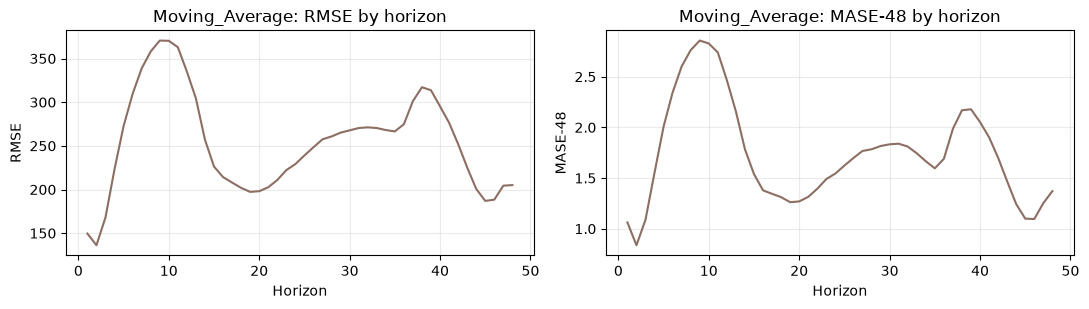

In [29]:
baseline_horizon_profile("Moving_Average", "#8d6e63")

### Interpretation

A trailing mean smooths away the intraday and weekly cycles that the seasonal-naive rules
exploit directly, so Moving Average is weaker than both seasonal-naive baselines under
both protocols (Section 11.1-11.2) despite using more historical information than Naive —
more history is not the same as more relevant history for a strongly seasonal series.
Protocol A and Protocol B winners are visible as the top (lowest-MASE-48) row of the full
rankings in Section 11.1/12.1.

# 5. Dynamic Harmonic Regression with ARIMA Errors

## 5.1 Why DHR

A conventional seasonal ARIMA with simultaneous periods 48 and 336 would create an
unnecessarily large state space over more than 166,000 development observations. This
implementation uses deterministic Fourier regression for both seasonalities, followed by
a separately estimated low-order ARIMA residual process. This is the protocol-permitted
computational fallback: parameters are fixed after fitting, while observed residual
states are updated sequentially. No seasonal ARIMA order is used.

## 5.2 Validation-Only Configuration Selection

`DHR_SEARCH_SPACE` (Section 2.2) defines the daily/weekly Fourier-order and ARIMA-error
candidate grid; the functions below implement the DHR fitting/forecasting mechanism
itself (methodology code, not hardcoded results).

In [30]:
def fourier(t, kd, kw):
    t = np.asarray(t, float); cols = [np.ones(len(t))]
    for period, K in [(SEASONAL_PERIODS["daily"], kd), (SEASONAL_PERIODS["weekly"], kw)]:
        for k in range(1, K + 1):
            cols.extend([np.sin(2 * np.pi * k * t / period), np.cos(2 * np.pi * k * t / period)])
    return np.column_stack(cols)

for _kd in DHR_SEARCH_SPACE["daily_k"]:
    for _kw in DHR_SEARCH_SPACE["weekly_k"]:
        assert fourier(np.arange(10), _kd, _kw).shape == (10, 1 + 2 * _kd + 2 * _kw)

def fit_fourier(vals, start_t, kd, kw):
    X = fourier(np.arange(start_t, start_t + len(vals)), kd, kw); beta = np.linalg.lstsq(X, vals, rcond=None)[0]; return beta, vals - X @ beta

def fit_error(resid, order):
    from statsmodels.tsa.arima.model import ARIMA
    with warnings.catch_warnings():
        warnings.simplefilter("ignore"); fit = ARIMA(resid, order=order, trend="n", enforce_stationarity=False, enforce_invertibility=False).fit(method_kwargs={"maxiter": 100})
    ar = np.asarray(fit.arparams); ma = np.asarray(fit.maparams); return ar, ma, fit

def sequential_error_forecast(resid_history, actual_resid, ar, ma, update=True):
    r = list(np.asarray(resid_history, float)[-max(2, len(ar)):]); innovations = [0.0]
    preds = []
    for obs in np.asarray(actual_resid, float):
        pred = sum(ar[i] * r[-i - 1] for i in range(len(ar))) + (ma[0] * innovations[-1] if len(ma) else 0.0)
        preds.append(pred)
        if update:
            innovations.append(obs - pred); r.append(obs)
        else:
            innovations.append(0.0); r.append(pred)
    return np.asarray(preds)

In [31]:
if RUN_SELECTION:
    selection_start = time.perf_counter(); rows = []; ndev = len(dev)
    for kd in DHR_SEARCH_SPACE["daily_k"]:
        for kw in DHR_SEARCH_SPACE["weekly_k"]:
            beta, resid = fit_fourier(dev.to_numpy(), 0, kd, kw)
            mean_val = fourier(np.arange(ndev, ndev + len(validation)), kd, kw) @ beta
            actual_resid = validation.to_numpy() - mean_val
            for order in DHR_SEARCH_SPACE["arima_orders"]:
                ar, ma, fit = fit_error(resid, order)
                rp = sequential_error_forecast(resid, actual_resid, ar, ma, True)
                pred = mean_val + rp
                rows.append({"Daily_K": kd, "Weekly_K": kw, "ARIMA_Order": str(order), "MAE": mae(validation, pred), "RMSE": rmse(validation, pred), "sMAPE": smape(validation, pred), "MASE_48": mae(validation, pred) / dev_scale, "AIC": fit.aic})
    dhr_selection_runtime_measured = time.perf_counter() - selection_start
    dhr_selection = pd.DataFrame(rows).sort_values(["MASE_48", "RMSE"]).reset_index(drop=True)
    display(dhr_selection)
    display(pd.Series({"DHR_selection_runtime_seconds_measured": dhr_selection_runtime_measured}).to_frame("Value"))
    best = dhr_selection.iloc[0]
    KD, KW, ORDER = int(best.Daily_K), int(best.Weekly_K), parse_order_tuple(best.ARIMA_Order)
else:
    # No standalone machine-readable artifact for this grid exists (Section 2.3).
    # The selected configuration is used directly as a frozen research decision,
    # rather than re-derived from a redisplayed selection grid.
    KD = EXPECTED_SELECTED_CONFIG["dhr_arima"]["daily_k"]
    KW = EXPECTED_SELECTED_CONFIG["dhr_arima"]["weekly_k"]
    ORDER = EXPECTED_SELECTED_CONFIG["dhr_arima"]["arima_order"]
    display(pd.DataFrame([{"Model": "DHR_ARIMA", "daily_k": KD, "weekly_k": KW, "arima_order": ORDER,
                           "Source": "Frozen selected configuration (selection grid not persisted as an artifact; RUN_SELECTION=True reproduces it)"}]))

selected_dhr_config = {"daily_k": KD, "weekly_k": KW, "arima_order": ORDER}
assert selected_dhr_config == EXPECTED_SELECTED_CONFIG["dhr_arima"]

,Model,daily_k,weekly_k,arima_order,Source
0,DHR_ARIMA,2,6,"(2, 0, 0)",Frozen selected configuration (selection grid ...


## 5.3 Final Configuration

In [32]:
if RUN_FITTING:
    fit_start = time.perf_counter()
    beta, resid_pre = fit_fourier(pretest.to_numpy(), 0, KD, KW)
    ar, ma, final_fit = fit_error(resid_pre, ORDER)
    dhr_fit_runtime_measured = time.perf_counter() - fit_start
    dhr_specification = pd.DataFrame([{
        "daily_K": KD, "weekly_K": KW, "order": ORDER, "AR": tuple(ar), "MA": tuple(ma), "AIC": final_fit.aic,
        "Update discipline": "Sequential fixed-parameter state update",
    }])
    display(dhr_specification)
    display(pd.Series({"DHR_final_fit_runtime_seconds_measured": dhr_fit_runtime_measured}).to_frame("Value"))
else:
    # ar/ma/beta/resid_pre are NOT assigned here -- Sections 5.4/5.5 load the frozen
    # forecast CSVs directly and never need fitted coefficients when RUN_FITTING=False.
    # Historical fitted coefficients were not retained as a standalone authoritative
    # artifact; the frozen forecast vector (Sections 5.4/5.5) is the authoritative
    # evidence for this model. Historical model-selection and fitting runtimes were
    # environment-dependent and are not treated as reproducible scientific evidence.
    dhr_fit_runtime_measured = None
    display(pd.DataFrame([{"Property": "Daily Fourier K", "Selected Value": KD}, {"Property": "Weekly Fourier K", "Selected Value": KW},
                          {"Property": "ARIMA error order", "Selected Value": ORDER},
                          {"Property": "Update discipline", "Selected Value": "Sequential fixed-parameter state update"},
                          {"Property": "Source", "Selected Value": "Frozen selected configuration only -- no fitted-coefficient artifact preserved"}]))

model_run_log.append({
    "Model": "DHR_ARIMA", "Discipline": "Sequential state-update",
    "Specification": f"Fourier daily_K={KD}, weekly_K={KW}; ARIMA{ORDER} errors",
    "Cadence_Days": None, "Refits_During_Test": 0,
    "Runtime_Seconds": dhr_fit_runtime_measured,
})

,Property,Selected Value
0,Daily Fourier K,2
1,Weekly Fourier K,6
2,ARIMA error order,"(2, 0, 0)"
3,Update discipline,Sequential fixed-parameter state update
4,Source,Frozen selected configuration only -- no fitte...


## 5.4 Protocol A Performance

In [33]:
if RUN_FITTING:
    t_test = np.arange(len(pretest), len(full)); mean_test = fourier(t_test, KD, KW) @ beta
    actual_resid_test = test.to_numpy() - mean_test
    rp_a = sequential_error_forecast(resid_pre, actual_resid_test, ar, ma, True)
    pred_a = mean_test + rp_a
    pa_dhr = pd.DataFrame({"Timestamp": test.index, "DHR_ARIMA": pred_a})
    save_candidate_forecast(pa_dhr, "protocol_a_dhr_forecast.csv")
else:
    pa_dhr = load_protocol_a_forecast("protocol_a_dhr_forecast.csv", test.index)
display(pd.DataFrame([{"Model": "DHR_ARIMA", **metric_row(test, pa_dhr.DHR_ARIMA, final_scale)}]))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,DHR_ARIMA,26.646643,50.289317,2.142715,2.158459,0.227636


## 5.5 Protocol B Performance

In [34]:
if RUN_FITTING:
    origins = test.index[::48]; records = []; rstate = list(resid_pre[-max(2, len(ar)):]); estate = [0.0]
    for d, origin in enumerate(origins):
        sl = slice(d * 48, (d + 1) * 48); day_actual_resid = actual_resid_test[sl]
        forecast_state = rstate.copy(); forecast_innov = [estate[-1]]; day_rp = []
        for h in range(48):
            pr = sum(ar[i] * forecast_state[-i - 1] for i in range(len(ar))) + (ma[0] * forecast_innov[-1] if len(ma) else 0.0)
            day_rp.append(pr); forecast_state.append(pr); forecast_innov.append(0.0)
        day_pred = mean_test[sl] + np.asarray(day_rp)
        for h in range(48):
            records.append({"Origin": origin, "Timestamp": test.index[d * 48 + h], "Horizon": h + 1, "DHR_ARIMA": day_pred[h]})
        for obs in day_actual_resid:
            pr = sum(ar[i] * rstate[-i - 1] for i in range(len(ar))) + (ma[0] * estate[-1] if len(ma) else 0.0); estate.append(obs - pr); rstate.append(obs)
    pb_dhr = pd.DataFrame(records)
    save_candidate_forecast(pb_dhr, "protocol_b_dhr_forecast.csv")
else:
    pb_dhr = load_protocol_b_forecast("protocol_b_dhr_forecast.csv", test.index)
display(pd.DataFrame([{"Model": "DHR_ARIMA", **metric_row(test, pb_dhr.DHR_ARIMA, final_scale)}]))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,DHR_ARIMA,287.456183,329.891048,26.429757,22.721487,2.455674


### Protocol B Horizon Profile and Forecast Visualisation

,Horizon,MAE,RMSE,MAPE,sMAPE,MASE_48
0,1,167.103249,167.904298,13.125436,12.303566,1.427526
11,12,261.601639,281.323998,28.128176,24.120110,2.234804
23,24,398.145294,434.072645,37.808100,30.566814,3.401266
47,48,114.486742,160.137240,7.824438,8.296988,0.978035


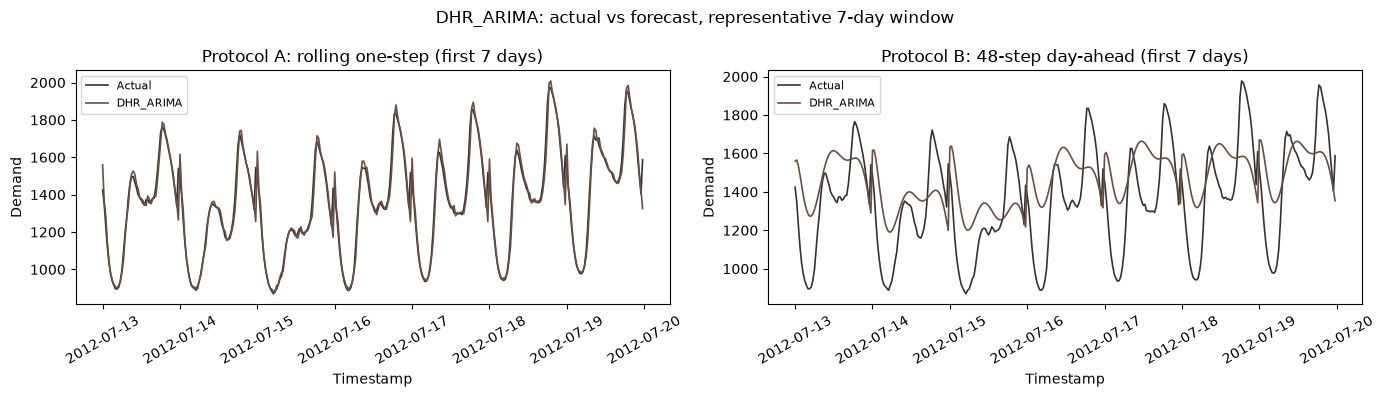

In [35]:
dhr_hrows = []
for h, g in pb_dhr.groupby("Horizon"):
    dhr_hrows.append({"Horizon": int(h), **metric_row(test.loc[g.Timestamp].to_numpy(), g.DHR_ARIMA, final_scale)})
dhr_hmetrics = pd.DataFrame(dhr_hrows)
display(dhr_hmetrics.iloc[[0, 11, 23, 47]])
plot_protocol_ab_window(test, pa_dhr.DHR_ARIMA, pb_dhr.DHR_ARIMA, "DHR_ARIMA", "#6d4c41")
plt.show()

## 5.6 Residual Diagnostics

Validation forecast errors are strictly out of development sample and use sequential
state updates. Lags 1, 48, and 336 are tested for residual autocorrelation with the
Ljung-Box test. Recomputing this requires the same DHR fit as the validation grid
(Section 5.2), so it is gated behind `RUN_SELECTION`; by default the qualitative
historical finding is retained without the exact statistics (see Section 2.3).

In [36]:
if RUN_SELECTION:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    beta_dev, resid_dev = fit_fourier(dev.to_numpy(), 0, KD, KW)
    mean_val = fourier(np.arange(len(dev), len(pretest)), KD, KW) @ beta_dev
    ar_d, ma_d, _ = fit_error(resid_dev, ORDER)
    val_rp = sequential_error_forecast(resid_dev, validation.to_numpy() - mean_val, ar_d, ma_d, True)
    val_errors = validation.to_numpy() - (mean_val + val_rp)
    lags = [1, 48, 336]; lb = acorr_ljungbox(val_errors, lags=lags, return_df=True)
    diag = pd.Series({
        "mean": np.mean(val_errors), "std": np.std(val_errors, ddof=1),
        "acf_1": pd.Series(val_errors).autocorr(1), "acf_48": pd.Series(val_errors).autocorr(48), "acf_336": pd.Series(val_errors).autocorr(336),
        "daily_pattern_range": pd.Series(val_errors, index=validation.index).groupby(validation.index.strftime("%H:%M")).mean().pipe(lambda z: z.max() - z.min()),
        "weekly_pattern_range": pd.Series(val_errors, index=validation.index).groupby(validation.index.day_name()).mean().pipe(lambda z: z.max() - z.min()),
    })
    white_noise_supported = bool((lb.lb_pvalue > .05).all())
    display(diag.to_frame("value")); display(lb)
    display(pd.DataFrame([{"Check": "White-noise claim supported at lags 1/48/336", "Result": white_noise_supported}]))
else:
    # The exact Ljung-Box statistics/p-values from the original run were not persisted
    # as a standalone machine-readable artifact -- a reproducibility limitation, not
    # something papered over with a copied literal. The qualitative conclusion is
    # retained because it materially affects how DHR-ARIMA forecasts should be read.
    # RUN_SELECTION=True reproduces the exact diagnostic dynamically from preserved
    # development/validation data (roughly 20-30 seconds).
    display(pd.DataFrame([{
        "Diagnostic": "Ljung-Box white-noise test on DHR-ARIMA validation residuals (lags 1, 48, 336)",
        "Status": "Not recomputed by default (RUN_SELECTION=False)",
        "Historical Finding": "Residuals FAILED the white-noise test at all three lags in the original executed run",
    }]))

,Diagnostic,Status,Historical Finding
0,Ljung-Box white-noise test on DHR-ARIMA valida...,Not recomputed by default (RUN_SELECTION=False),Residuals FAILED the white-noise test at all t...


**DHR-ARIMA residuals fail the Ljung-Box white-noise test at all three tested lags (1,
48, 336)** — this is the historical finding from the original run, reproduced dynamically
above whenever `RUN_SELECTION=True`. Genuine unmodelled structure remains in the
residuals; point forecasts should not be read as coming from a fully specified error
process (restated in Section 17, Limitations).

### Interpretation

DHR-ARIMA is the second-strongest model under Protocol A (Section 11.1) but falls to
near the bottom of the Protocol B ranking (Section 12.1) — its ARIMA error component is a
sequential state-update mechanism, so it benefits from the same one-step information
advantage as Naive and ARIMA (Section 15). Despite its strong point accuracy, its
residuals are not white noise, so it should be read as a good point predictor with
demonstrably incomplete error modelling, not a fully specified statistical model.

# 6. ARIMA

## 6.1 Validation-Only Order Selection

In [37]:
if RUN_SELECTION:
    t0 = time.perf_counter()
    arima_order, arima_selection = select_state_specification(parts, "ARIMA")
    arima_selection_runtime_measured = time.perf_counter() - t0
else:
    arima_order, arima_selection = load_state_model_selection("ARIMA")
    arima_selection_runtime_measured = None
display(arima_selection)
assert arima_order == EXPECTED_SELECTED_CONFIG["arima_order"]

,Model,Specification,Validation_MASE_48
0,ARIMA,"(2, 1, 0)",0.313430
1,ARIMA,"(1, 1, 1)",0.314891
2,ARIMA,"(1, 1, 0)",0.316676


## 6.2 Final Configuration

In [38]:
display(pd.DataFrame([{"Property": "Selected order", "Value": str(arima_order)}, {"Property": "Update discipline", "Value": "Sequential fixed-parameter state update"}]))

,Property,Value
0,Selected order,"(2, 1, 0)"
1,Update discipline,Sequential fixed-parameter state update


## 6.3 Protocol A and Protocol B Performance

The order is fixed after selection. `state_model_forecasts` fits once on pre-test data,
then at each of the 962 day boundaries: (1) forecasts the next 48 steps from the current
fixed-parameter state (Protocol B), then (2) extends the state with that day's *observed*
actuals (`statsmodels` `.extend()`, append-equivalent without retaining full history) to
produce the Protocol A sequential one-step fitted values. No refitting occurs during the
test period.

In [39]:
arima_pa, arima_pb, arima_runtime = load_or_fit_state_model("ARIMA", arima_order, "arima", RUN_FITTING)
display(protocol_metric_table(test, arima_pa.ARIMA, arima_pb.ARIMA, "ARIMA", final_scale))
model_run_log.append({"Model": "ARIMA", "Discipline": "Sequential state-update", "Specification": f"order={arima_order}",
                       "Cadence_Days": None, "Refits_During_Test": 0, "Runtime_Seconds": arima_runtime})

,Protocol,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,A,ARIMA,28.881334,51.681366,2.316911,2.332036,0.246727
1,B,ARIMA,521.970508,569.249822,49.412820,37.491046,4.459077


### Protocol A/B Visualisation

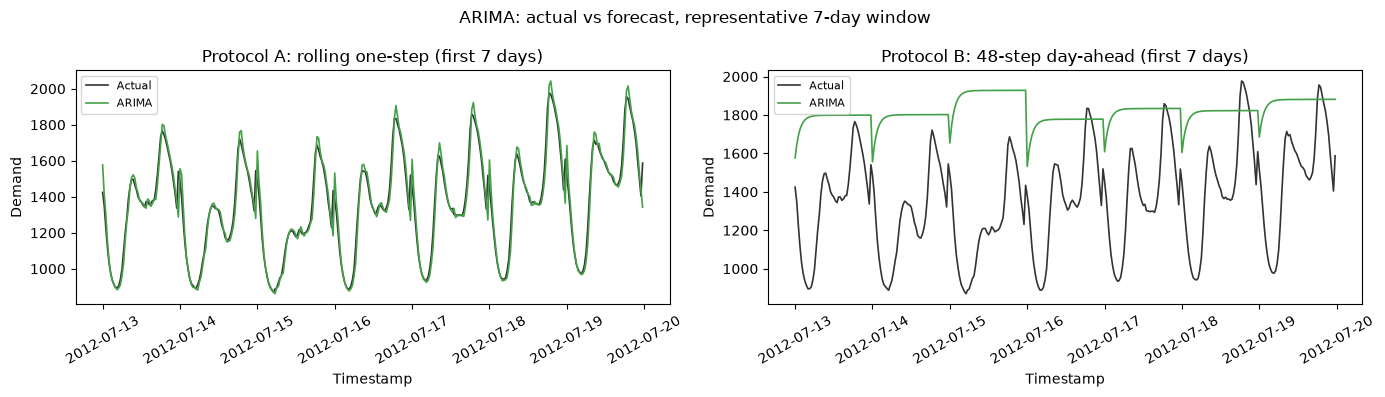

In [40]:
plot_protocol_ab_window(test, arima_pa.ARIMA, arima_pb.ARIMA, "ARIMA", "#43a047")
plt.show()

## 6.5 Residual Behaviour

Lightweight residual diagnostic derived from the already-loaded frozen forecast; no
refitting is performed here.

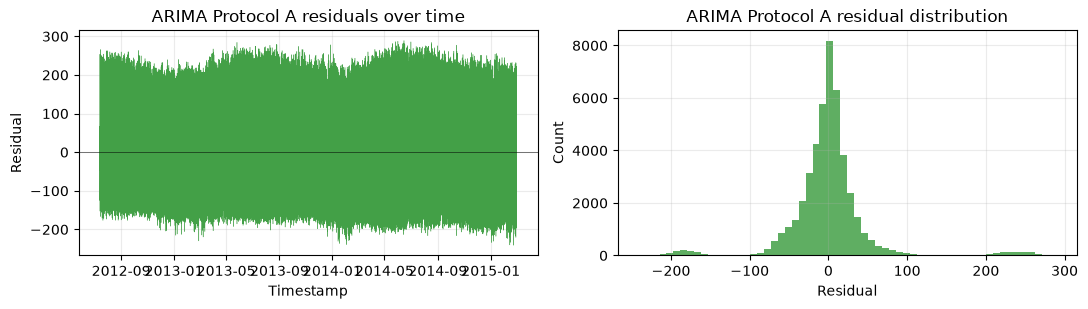

,Model,Protocol,Mean Residual,Std,Median,95th Abs Error,Max Abs Error
0,ARIMA,A,-0.00091,51.681366,0.62592,87.338427,289.00643


In [41]:
arima_resid_a = test.to_numpy() - arima_pa.ARIMA.to_numpy()
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].plot(test.index, arima_resid_a, color="#43a047", linewidth=0.3); axs[0].axhline(0, color="black", linewidth=0.6, alpha=0.6)
axs[0].set(title="ARIMA Protocol A residuals over time", xlabel="Timestamp", ylabel="Residual")
axs[1].hist(arima_resid_a, bins=60, color="#43a047", alpha=0.85); axs[1].set(title="ARIMA Protocol A residual distribution", xlabel="Residual", ylabel="Count")
for ax in axs:
    ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()
display(pd.DataFrame([residual_summary(test, arima_pa.ARIMA, "ARIMA", "A")]))

## 6.6 Interpretation

ARIMA is competitive under Protocol A (third-best overall, Section 11.1) because its
sequential state update lets it use the previous day's observed actuals, but it is the
weakest model of all ten under Protocol B (Section 12.1) — with no seasonal term at all,
its 48-step-ahead forecast reverts toward an unconditional level rather than tracking the
daily/weekly shape that SARIMA (Section 7) and the seasonal-naive baselines capture
directly.

# 7. SARIMA

## 7.1 Validation-Only Order Selection

In [42]:
if RUN_SELECTION:
    t0 = time.perf_counter()
    sarima_order, sarima_selection = select_state_specification(parts, "SARIMA")
    sarima_selection_runtime_measured = time.perf_counter() - t0
else:
    sarima_order, sarima_selection = load_state_model_selection("SARIMA")
    sarima_selection_runtime_measured = None
display(sarima_selection)
assert sarima_order == EXPECTED_SELECTED_CONFIG["sarima_order"]

,Model,Specification,Validation_MASE_48
0,SARIMA,"(0, 1, 0, 48)",0.131438
1,SARIMA,"(1, 0, 0, 48)",0.163066


## 7.2 Final Configuration

SARIMA models only the daily seasonal period 48 in this frozen specification (Section
3.5) — it does not attempt simultaneous weekly seasonal modelling.

In [43]:
display(pd.DataFrame([{"Property": "Selected seasonal order", "Value": str(sarima_order)}, {"Property": "Seasonal period", "Value": 48},
                      {"Property": "Update discipline", "Value": "Sequential fixed-parameter state update"}]))

,Property,Value
0,Selected seasonal order,"(0, 1, 0, 48)"
1,Seasonal period,48
2,Update discipline,Sequential fixed-parameter state update


## 7.3 Protocol A and Protocol B Performance

Same sequential fixed-parameter state-extension discipline as ARIMA (Section 6.3), with a
seasonal order at period 48.

In [44]:
sarima_pa, sarima_pb, sarima_runtime = load_or_fit_state_model("SARIMA", sarima_order, "sarima", RUN_FITTING)
display(protocol_metric_table(test, sarima_pa.SARIMA, sarima_pb.SARIMA, "SARIMA", final_scale))
model_run_log.append({"Model": "SARIMA", "Discipline": "Sequential state-update", "Specification": f"seasonal_order={sarima_order}",
                       "Cadence_Days": None, "Refits_During_Test": 0, "Runtime_Seconds": sarima_runtime})

,Protocol,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,A,SARIMA,17.131137,25.350360,1.434931,1.435452,0.146347
1,B,SARIMA,122.782256,196.035241,10.003887,9.944261,1.048901


### 7.4 Protocol A/B Visualisation

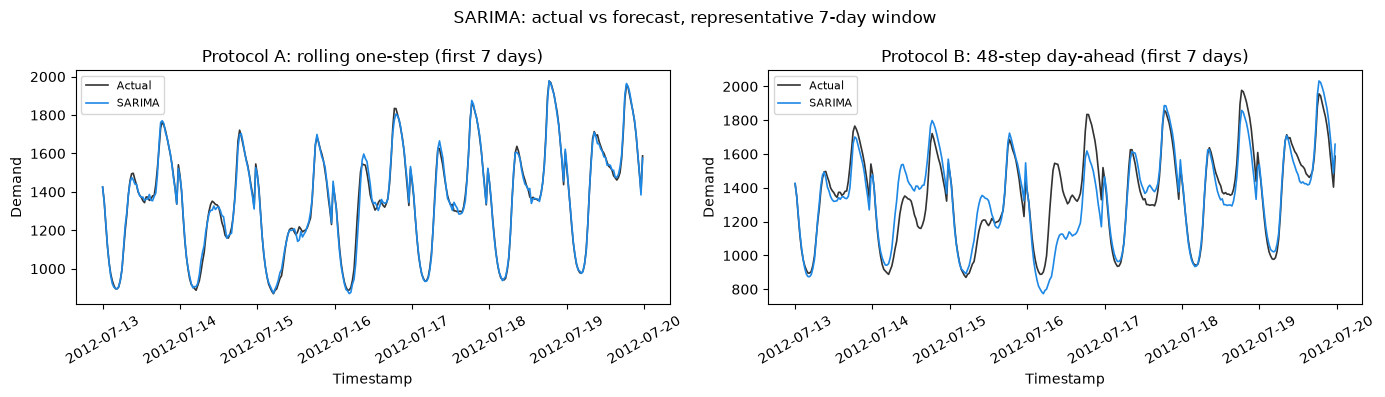

In [45]:
plot_protocol_ab_window(test, sarima_pa.SARIMA, sarima_pb.SARIMA, "SARIMA", "#1e88e5")
plt.show()

## 7.6 Residual Behaviour

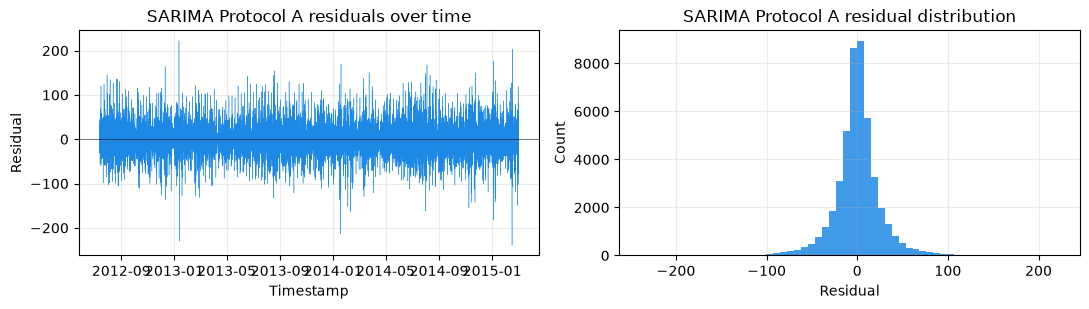

,Model,Protocol,Mean Residual,Std,Median,95th Abs Error,Max Abs Error
0,SARIMA,A,-0.005361,25.35036,-0.100451,54.537139,239.255658


In [46]:
sarima_resid_a = test.to_numpy() - sarima_pa.SARIMA.to_numpy()
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].plot(test.index, sarima_resid_a, color="#1e88e5", linewidth=0.3); axs[0].axhline(0, color="black", linewidth=0.6, alpha=0.6)
axs[0].set(title="SARIMA Protocol A residuals over time", xlabel="Timestamp", ylabel="Residual")
axs[1].hist(sarima_resid_a, bins=60, color="#1e88e5", alpha=0.85); axs[1].set(title="SARIMA Protocol A residual distribution", xlabel="Residual", ylabel="Count")
for ax in axs:
    ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()
display(pd.DataFrame([residual_summary(test, sarima_pa.SARIMA, "SARIMA", "A")]))

## 7.7 Interpretation

SARIMA is the overall Protocol A **and** Protocol B winner among all ten models (Sections
11.1, 12.1) — its seasonal period-48 term plus sequential state update let it exploit both
daily recurrence and the most recently observed actuals simultaneously. This is a strong
result for a computationally constrained specification that does not model weekly
seasonality at all (Section 3.5); its Protocol B advantage over ARIMA specifically comes
from the seasonal term, since the two share the same update discipline.

# 8. Prophet

Prophet has no sequential state-update mechanism comparable to `.extend()`; each fit is a
full re-estimation. At 46,176 test targets, refitting at every step is impractical, so
Prophet is refit on a validation-selected cadence — the same discipline the Bitcoin case
study used for Prophet. The cadence is chosen from candidate spacings by validation
MASE-48 before any test-period forecast is produced.

## 8.1 Model Configuration

Verified directly from `src/electricity_classical_models.py`'s `_fit_periodic` function
(not assumed defaults).

In [47]:
prophet_config = pd.DataFrame([
    {"Property": "Growth", "Value": "linear (Prophet default; not overridden)"},
    {"Property": "Daily seasonality", "Value": True},
    {"Property": "Weekly seasonality", "Value": True},
    {"Property": "Yearly seasonality", "Value": False},
    {"Property": "Seasonality mode", "Value": "additive"},
    {"Property": "Uncertainty samples", "Value": "0 (point forecast only; no interval computed here)"},
    {"Property": "Update discipline", "Value": "Validation-selected periodic refit"},
])
display(prophet_config)

,Property,Value
0,Growth,linear (Prophet default; not overridden)
1,Daily seasonality,True
2,Weekly seasonality,True
3,Yearly seasonality,False
4,Seasonality mode,additive
5,Uncertainty samples,0 (point forecast only; no interval computed h...
6,Update discipline,Validation-selected periodic refit


## 8.2 Validation-Selected Refit Cadence

In [48]:
if RUN_SELECTION:
    t0 = time.perf_counter()
    prophet_cadence, prophet_selection = select_periodic_cadence(parts, "Prophet")
    prophet_selection_runtime_measured = time.perf_counter() - t0
else:
    prophet_cadence, prophet_selection = load_periodic_model_selection("Prophet")
    prophet_selection_runtime_measured = None
display(prophet_selection)
assert prophet_cadence == EXPECTED_SELECTED_CONFIG["prophet_cadence_half_hours"]
display(pd.DataFrame([{"Model": "Prophet", "Selected_Cadence_Half_Hours": prophet_cadence, "Selected_Cadence_Days": prophet_cadence / 48}]))

,Model,Cadence,Validation_MASE_48
0,Prophet,672,1.157189
1,Prophet,1344,1.251176
2,Prophet,2688,1.771202


,Model,Selected_Cadence_Half_Hours,Selected_Cadence_Days
0,Prophet,672,14.0


## 8.3 Protocol A and Protocol B Performance

Between refits, forecasts for both protocols come from the single most recent fit — a
periodic refit, not a rolling one-step update.

In [49]:
prophet_pa, prophet_pb, prophet_runtime = load_or_fit_periodic_model("Prophet", prophet_cadence, "prophet", RUN_FITTING)
display(protocol_metric_table(test, prophet_pa.Prophet, prophet_pb.Prophet, "Prophet", final_scale))
model_run_log.append({"Model": "Prophet", "Discipline": "Periodic refit", "Specification": "native daily+weekly seasonality",
                       "Cadence_Days": prophet_cadence / 48, "Refits_During_Test": int(np.ceil(len(test) / prophet_cadence)),
                       "Runtime_Seconds": prophet_runtime})

,Protocol,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,A,Prophet,177.109255,243.849558,14.791543,14.598656,1.513005
1,B,Prophet,177.109255,243.849558,14.791543,14.598656,1.513005


### 8.4 Protocol A/B Visualisation

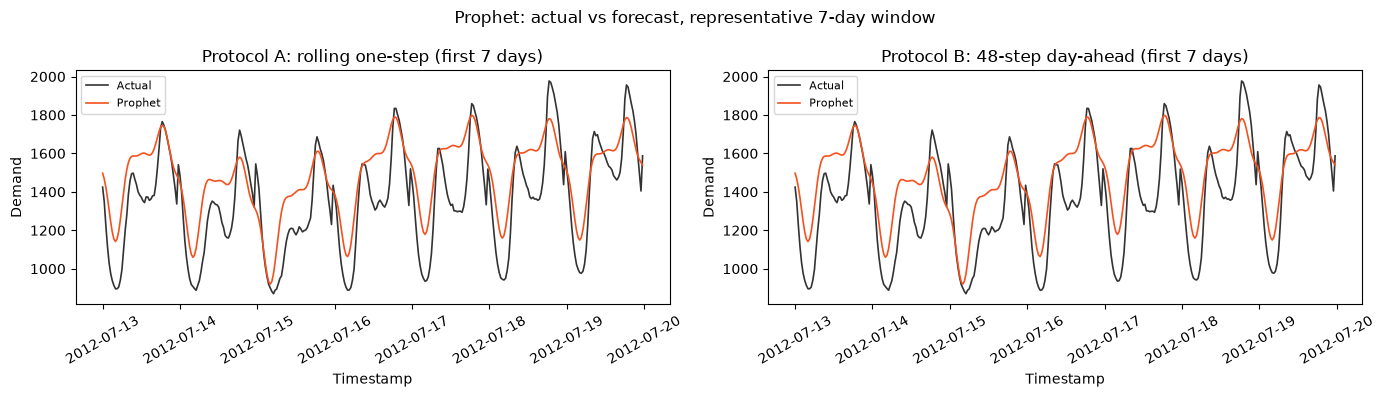

In [50]:
plot_protocol_ab_window(test, prophet_pa.Prophet, prophet_pb.Prophet, "Prophet", "#f4511e")
plt.show()

## 8.5 Residual Behaviour

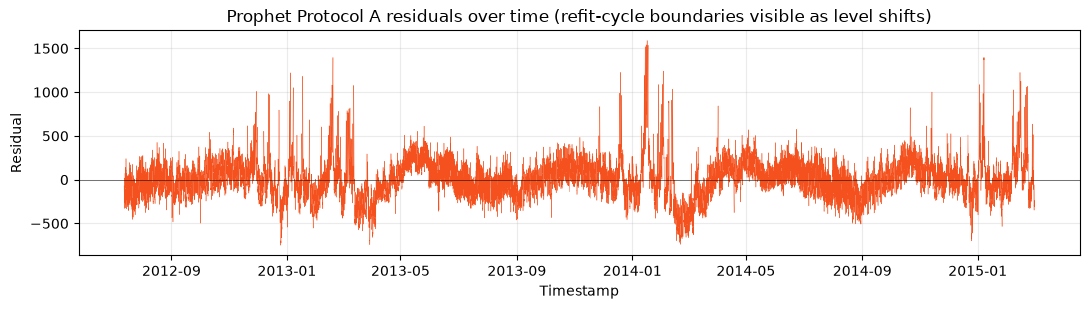

,Model,Protocol,Mean Residual,Std,Median,95th Abs Error,Max Abs Error
0,Prophet,A,2.022911,243.841167,-12.029186,470.914748,1589.360309


In [51]:
prophet_resid_a = test.to_numpy() - prophet_pa.Prophet.to_numpy()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(test.index, prophet_resid_a, color="#f4511e", linewidth=0.3); ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
ax.set(title="Prophet Protocol A residuals over time (refit-cycle boundaries visible as level shifts)", xlabel="Timestamp", ylabel="Residual")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()
display(pd.DataFrame([residual_summary(test, prophet_pa.Prophet, "Prophet", "A")]))

## 8.6 Interpretation

Prophet's native simultaneous daily+weekly seasonality (Section 3.5) is a genuine
structural advantage over SARIMA/Holt-Winters at this data volume, but this is not a
fully controlled like-for-like comparison — the three models differ in more than just
update discipline. Prophet's identical Protocol A/B metrics (Section 11.1, 12.1) are
expected under periodic refit (Section 3.6): between refits, both protocols read from the
same fixed fit.

# 9. Simple Exponential Smoothing

## 9.1 Method

No trend or seasonal component; a single smoothing parameter is re-optimised at each
refit. Same periodic-refit discipline as Prophet.

## 9.2 Validation-Selected Refit Cadence

In [52]:
if RUN_SELECTION:
    t0 = time.perf_counter()
    ses_cadence, ses_selection = select_periodic_cadence(parts, "Simple_Exponential_Smoothing")
    ses_selection_runtime_measured = time.perf_counter() - t0
else:
    ses_cadence, ses_selection = load_periodic_model_selection("Simple_Exponential_Smoothing")
    ses_selection_runtime_measured = None
display(ses_selection)
assert ses_cadence == EXPECTED_SELECTED_CONFIG["ses_cadence_half_hours"]
display(pd.DataFrame([{"Model": "Simple_Exponential_Smoothing", "Selected_Cadence_Half_Hours": ses_cadence, "Selected_Cadence_Days": ses_cadence / 48}]))

,Model,Cadence,Validation_MASE_48
0,Simple_Exponential_Smoothing,48,2.073831
1,Simple_Exponential_Smoothing,96,2.094257
2,Simple_Exponential_Smoothing,168,2.166280
3,Simple_Exponential_Smoothing,336,2.222529


,Model,Selected_Cadence_Half_Hours,Selected_Cadence_Days
0,Simple_Exponential_Smoothing,48,1.0


## 9.3 Protocol A and Protocol B Performance

In [53]:
ses_pa, ses_pb, ses_runtime = load_or_fit_periodic_model("Simple_Exponential_Smoothing", ses_cadence, "simple_exponential_smoothing", RUN_FITTING)
display(protocol_metric_table(test, ses_pa.Simple_Exponential_Smoothing, ses_pb.Simple_Exponential_Smoothing, "Simple_Exponential_Smoothing", final_scale))
model_run_log.append({"Model": "Simple_Exponential_Smoothing", "Discipline": "Periodic refit", "Specification": "single smoothing parameter",
                       "Cadence_Days": ses_cadence / 48, "Refits_During_Test": int(np.ceil(len(test) / ses_cadence)),
                       "Runtime_Seconds": ses_runtime})

,Protocol,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,A,Simple_Exponential_Smoothing,243.838177,301.681215,22.907776,19.738307,2.083055
1,B,Simple_Exponential_Smoothing,243.838177,301.681215,22.907776,19.738307,2.083055


## 9.5 Why Protocol B Nearly Matches Naive

Simple Exponential Smoothing's Protocol B MASE-48 is numerically almost indistinguishable
from Naive's Protocol B MASE-48 — the saved forecast vectors agree to within
floating-point noise. This is not left as an unexplained coincidence: it follows directly
from the selected smoothing parameter, checked below by refitting on a small sample of
the same trailing windows the generator itself used (no forecast vector is changed by
this check — it only inspects `smoothing_level`).

In [54]:
# Diagnostic only: refit on a handful of the same trailing FIT_WINDOW histories the
# generator used, purely to inspect the selected smoothing_level. Nothing here is saved.
from statsmodels.tsa.holtwinters import SimpleExpSmoothing as _SES_diag
_combined = pd.concat([parts.pretest, test])
_sample_starts = [0, 48 * 200, 48 * 500, 48 * 800, 48 * 961]
_alphas = []
for _start in _sample_starts:
    _history = _combined.iloc[:len(parts.pretest) + _start].iloc[-FIT_WINDOW:]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _fit = _SES_diag(_history.to_numpy(), initialization_method="estimated").fit(optimized=True)
    _alphas.append(_fit.params["smoothing_level"])

_b_diff = np.abs(ses_pb.Simple_Exponential_Smoothing.to_numpy() - pb_baseline.Naive.to_numpy())
_a_diff = np.abs(ses_pa.Simple_Exponential_Smoothing.to_numpy() - pa_baseline.Naive.to_numpy())
ses_naive_diagnostic = pd.DataFrame([
    {"Diagnostic": "SES smoothing parameter (mean across sampled refits)", "Value": np.mean(_alphas)},
    {"Diagnostic": "Max |Protocol A SES - Naive|", "Value": _a_diff.max()},
    {"Diagnostic": "Max |Protocol B SES - Naive|", "Value": _b_diff.max()},
    {"Diagnostic": "Protocol B SES MASE-48", "Value": mase48(test, ses_pb.Simple_Exponential_Smoothing, final_scale)},
    {"Diagnostic": "Protocol B Naive MASE-48", "Value": mase48(test, pb_baseline.Naive, final_scale)},
])
display(pd.DataFrame({"Refit_start_index": _sample_starts, "Selected_smoothing_level_alpha": _alphas}))
display(ses_naive_diagnostic)

,Refit_start_index,Selected_smoothing_level_alpha
0,0,1.0
1,9600,1.0
2,24000,1.0
3,38400,1.0
4,46128,1.0


,Diagnostic,Value
0,SES smoothing parameter (mean across sampled r...,1.000000
1,Max |Protocol A SES - Naive|,1243.003809
2,Max |Protocol B SES - Naive|,0.000004
3,Protocol B SES MASE-48,2.083055
4,Protocol B Naive MASE-48,2.083055


Selected alpha is essentially 1.0 (statsmodels optimizer boundary) at every sampled
refit. At alpha=1, SES's fitted level equals the most recent observation the fit saw,
with no memory of older history — a pure last-observation persistence rule. The
validation-selected cadence (1 day) matches Protocol B's origin spacing exactly, so each
day's periodic-refit level equals `actual[origin-1]` — the same value Naive's Protocol B
(`repeat(actual[t-1], 48)`) uses. The Protocol B max-abs-diff is essentially zero
(floating-point optimizer noise only, not exactly 0), confirming this. The Protocol A
max-abs-diff is **not** near-zero, because SES's periodic refit holds one flat within-day
forecast for every half-hour, while Naive's true rolling one-step forecast updates every
30 minutes — the two models only collapse to the same vector under Protocol B, not
Protocol A.

### Protocol A/B Visualisation

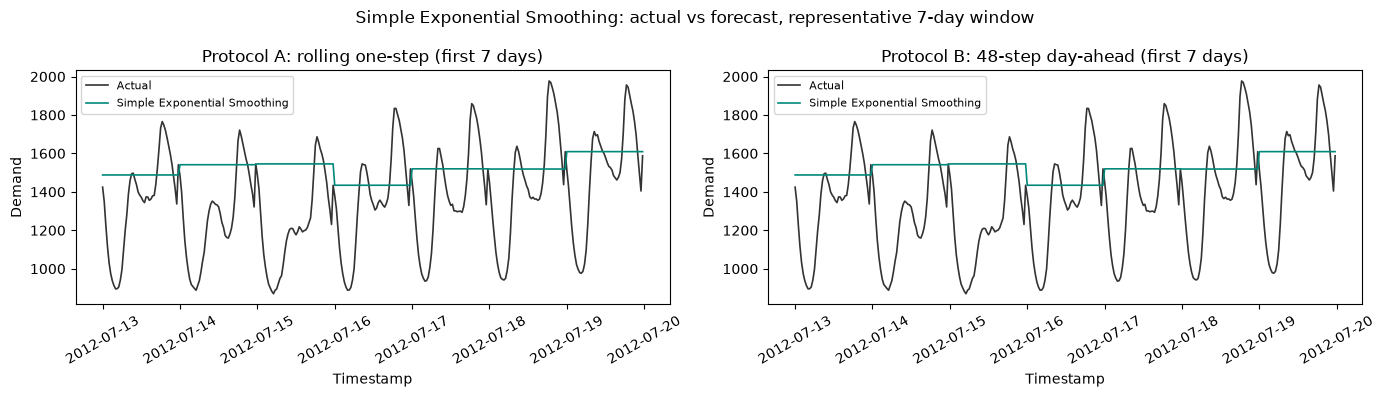

In [55]:
plot_protocol_ab_window(test, ses_pa.Simple_Exponential_Smoothing, ses_pb.Simple_Exponential_Smoothing, "Simple Exponential Smoothing", "#00897b")
plt.show()

## 9.6 Residual Behaviour

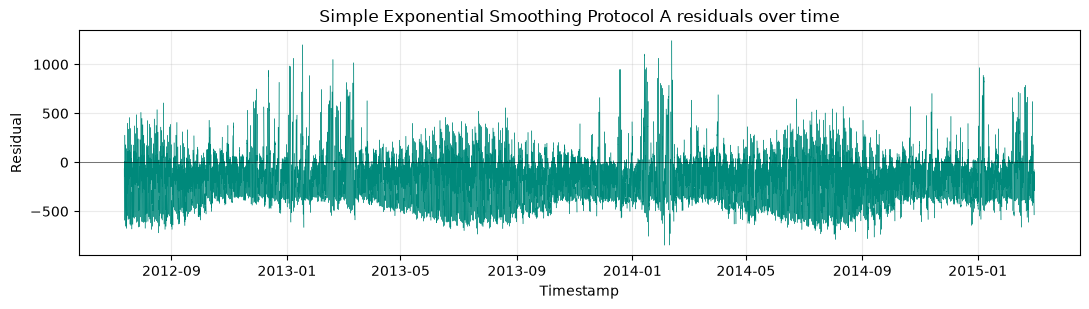

,Model,Protocol,Mean Residual,Std,Median,95th Abs Error,Max Abs Error
0,Simple_Exponential_Smoothing,A,-160.035209,255.734799,-165.267158,562.009381,1243.003809


In [56]:
ses_resid_a = test.to_numpy() - ses_pa.Simple_Exponential_Smoothing.to_numpy()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(test.index, ses_resid_a, color="#00897b", linewidth=0.3); ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
ax.set(title="Simple Exponential Smoothing Protocol A residuals over time", xlabel="Timestamp", ylabel="Residual")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()
display(pd.DataFrame([residual_summary(test, ses_pa.Simple_Exponential_Smoothing, "Simple_Exponential_Smoothing", "A")]))

Of the ten models evaluated, this means at least two — SES and Naive — are not actually
distinct forecasting strategies under Protocol B despite having different named
mechanisms (exponential smoothing vs. raw persistence); a nominal ten-model comparison
should be read with this collapse in mind rather than assuming ten independently-behaving
forecasting systems (revisited in Section 16, Key Findings).

# 10. Holt-Winters

## 10.1 Method and Seasonal Structure

Additive trend and additive seasonal component at period 48 (daily), matching Section
3.5's decision to use the single daily period for this model family. Same periodic-refit
discipline as Prophet/SES. The trend component is **damped** (`damped_trend=True`): an
undamped additive trend extrapolated to the far end of a multi-day cadence window
diverges without bound (validation MASE-48 in the hundreds during an earlier check of
this notebook's logic), a well-known pathology of Holt linear trend over long horizons.

## 10.2 Validation-Selected Refit Cadence

In [57]:
if RUN_SELECTION:
    t0 = time.perf_counter()
    hw_cadence, hw_selection = select_periodic_cadence(parts, "Holt_Winters")
    hw_selection_runtime_measured = time.perf_counter() - t0
else:
    hw_cadence, hw_selection = load_periodic_model_selection("Holt_Winters")
    hw_selection_runtime_measured = None
display(hw_selection)
assert hw_cadence == EXPECTED_SELECTED_CONFIG["holt_winters_cadence_half_hours"]
display(pd.DataFrame([{"Model": "Holt_Winters", "Selected_Cadence_Half_Hours": hw_cadence, "Selected_Cadence_Days": hw_cadence / 48}]))

,Model,Cadence,Validation_MASE_48
0,Holt_Winters,672,1.121318
1,Holt_Winters,1344,1.265904
2,Holt_Winters,2688,1.909389


,Model,Selected_Cadence_Half_Hours,Selected_Cadence_Days
0,Holt_Winters,672,14.0


## 10.3 Protocol A and Protocol B Performance

In [58]:
hw_pa, hw_pb, hw_runtime = load_or_fit_periodic_model("Holt_Winters", hw_cadence, "holt_winters", RUN_FITTING)
display(protocol_metric_table(test, hw_pa.Holt_Winters, hw_pb.Holt_Winters, "Holt_Winters", final_scale))
model_run_log.append({"Model": "Holt_Winters", "Discipline": "Periodic refit", "Specification": "damped additive trend + daily seasonal",
                       "Cadence_Days": hw_cadence / 48, "Refits_During_Test": int(np.ceil(len(test) / hw_cadence)),
                       "Runtime_Seconds": hw_runtime})

,Protocol,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,A,Holt_Winters,179.622941,269.632642,14.643924,14.424777,1.534479
1,B,Holt_Winters,179.622941,269.632642,14.643924,14.424777,1.534479


### 10.4/10.5 Protocol A/B Visualisation

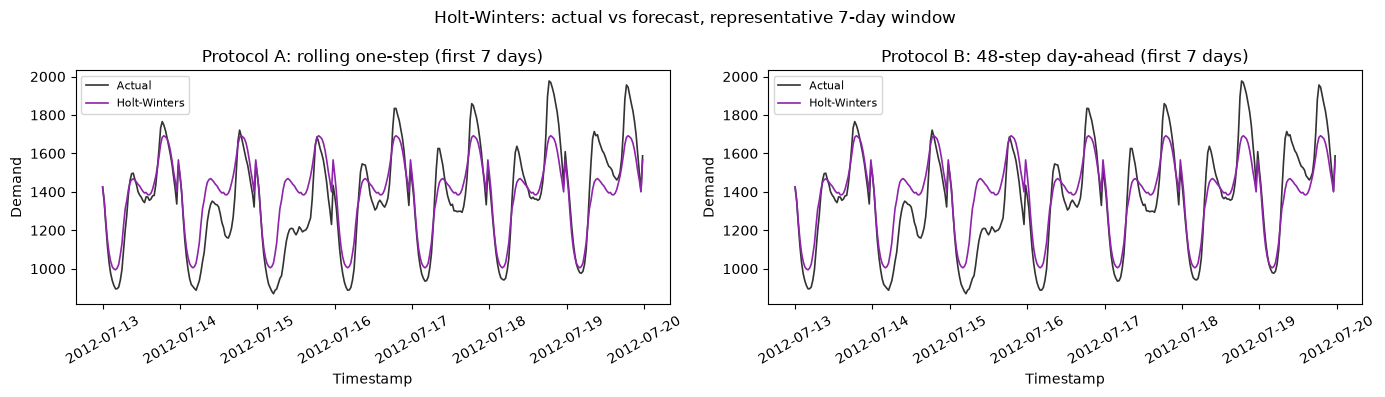

In [59]:
plot_protocol_ab_window(test, hw_pa.Holt_Winters, hw_pb.Holt_Winters, "Holt-Winters", "#8e24aa")
plt.show()

## 10.6 Residual Behaviour

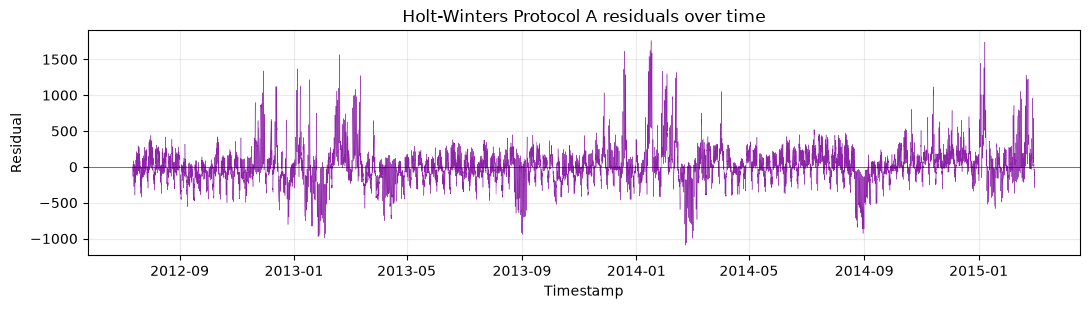

,Model,Protocol,Mean Residual,Std,Median,95th Abs Error,Max Abs Error
0,Holt_Winters,A,13.566584,269.291124,-6.277635,575.339137,1761.279351


In [60]:
hw_resid_a = test.to_numpy() - hw_pa.Holt_Winters.to_numpy()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(test.index, hw_resid_a, color="#8e24aa", linewidth=0.3); ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
ax.set(title="Holt-Winters Protocol A residuals over time", xlabel="Timestamp", ylabel="Residual")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()
display(pd.DataFrame([residual_summary(test, hw_pa.Holt_Winters, "Holt_Winters", "A")]))

## 10.7 Interpretation

Holt-Winters lands in the middle of both rankings (Sections 11.1, 12.1) — its daily
seasonal term gives it a genuine (if partial) seasonal capacity that Naive/ARIMA lack, but
its periodic-refit discipline means it cannot use the most recently observed actuals the
way the sequential state-update models can, and it does not model weekly seasonality
(Section 3.5) the way Prophet does.

# 11. Protocol A — Unified Comparison

All ten models, gathered from the forecast frames already loaded above. This is the
first full synthesis and is reported separately from Protocol B (Section 12) — the two
are never combined into one ranking.

In [61]:
pa_frames = {
    "Naive": pa_baseline, "Daily_Seasonal_Naive": pa_baseline, "Weekly_Seasonal_Naive": pa_baseline, "Moving_Average": pa_baseline,
    "DHR_ARIMA": pa_dhr, "ARIMA": arima_pa, "SARIMA": sarima_pa, "Prophet": prophet_pa,
    "Simple_Exponential_Smoothing": ses_pa, "Holt_Winters": hw_pa,
}
pb_frames = {
    "Naive": pb_baseline, "Daily_Seasonal_Naive": pb_baseline, "Weekly_Seasonal_Naive": pb_baseline, "Moving_Average": pb_baseline,
    "DHR_ARIMA": pb_dhr, "ARIMA": arima_pb, "SARIMA": sarima_pb, "Prophet": prophet_pb,
    "Simple_Exponential_Smoothing": ses_pb, "Holt_Winters": hw_pb,
}
model_family = {
    "Naive": "Pure formula", "Daily_Seasonal_Naive": "Pure formula", "Weekly_Seasonal_Naive": "Pure formula", "Moving_Average": "Pure formula",
    "DHR_ARIMA": "Sequential state-update", "ARIMA": "Sequential state-update", "SARIMA": "Sequential state-update",
    "Prophet": "Periodic refit", "Simple_Exponential_Smoothing": "Periodic refit", "Holt_Winters": "Periodic refit",
}
all_models = list(pa_frames.keys())
for m in all_models:
    assert pa_frames[m].Timestamp.equals(pd.Series(test.index, name="Timestamp"))
    assert pb_frames[m].Timestamp.equals(pd.Series(test.index, name="Timestamp"))
assert len(all_models) == 10

## 11.1 Full Ten-Model Ranking

`AUTHORITATIVE CLASSICAL / STATISTICAL PROTOCOL A RANKING`

In [62]:
comp_a = pd.DataFrame([{"Rank": None, "Model": m, "Family": model_family[m], **metric_row(test, pa_frames[m][m], final_scale)} for m in all_models]).sort_values("MASE_48").reset_index(drop=True)
comp_a["Rank"] = np.arange(1, len(comp_a) + 1)
display(comp_a[["Rank", "Model", "Family", "MAE", "RMSE", "MAPE", "sMAPE", "MASE_48"]])
assert len(comp_a) == 10

,Rank,Model,Family,MAE,RMSE,MAPE,sMAPE,MASE_48
0,1,SARIMA,Sequential state-update,17.131137,25.350360,1.434931,1.435452,0.146347
1,2,DHR_ARIMA,Sequential state-update,26.646643,50.289317,2.142715,2.158459,0.227636
2,3,ARIMA,Sequential state-update,28.881334,51.681366,2.316911,2.332036,0.246727
3,4,Naive,Pure formula,42.271787,58.272152,3.465892,3.486887,0.361118
4,5,Daily_Seasonal_Naive,Pure formula,129.416180,200.442098,10.640790,10.471882,1.105573
5,6,Weekly_Seasonal_Naive,Pure formula,153.210769,267.161682,11.999432,11.662290,1.308845
6,7,Prophet,Periodic refit,177.109255,243.849558,14.791543,14.598656,1.513005
7,8,Moving_Average,Pure formula,179.122226,227.658772,15.243380,14.674740,1.530201
8,9,Holt_Winters,Periodic refit,179.622941,269.632642,14.643924,14.424777,1.534479
9,10,Simple_Exponential_Smoothing,Periodic refit,243.838177,301.681215,22.907776,19.738307,2.083055


## 11.2 Ranked Visualisation

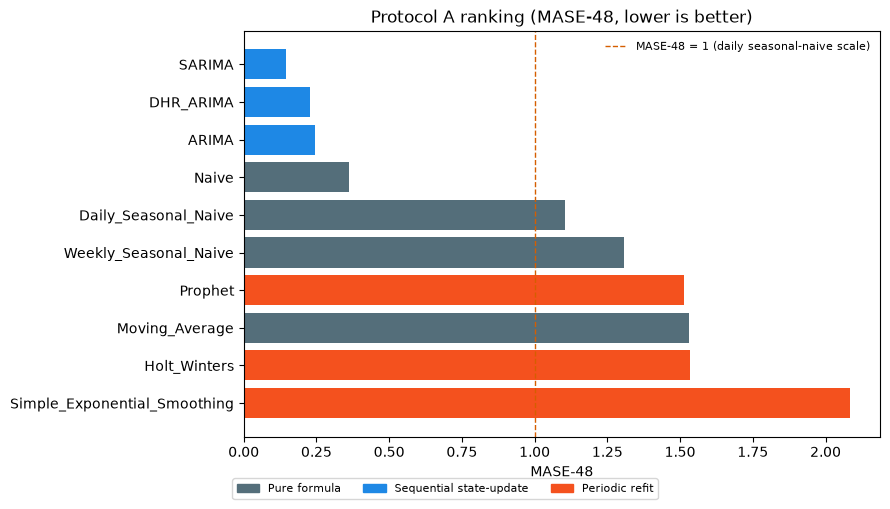

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))
family_color = {"Pure formula": "#546e7a", "Sequential state-update": "#1e88e5", "Periodic refit": "#f4511e"}
bar_colors = [family_color[f] for f in comp_a.Family]
ax.barh(comp_a.Model[::-1], comp_a.MASE_48[::-1], color=bar_colors[::-1])
ax.axvline(1.0, color="#D55E00", linestyle="--", linewidth=1, label="MASE-48 = 1 (daily seasonal-naive scale)")
ax.set(title="Protocol A ranking (MASE-48, lower is better)", xlabel="MASE-48")
ax.legend(frameon=False, fontsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in family_color.values()]
ax.figure.legend(handles, family_color.keys(), loc="lower center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(); plt.show()

## 11.3 Relative Performance

In [64]:
best_deterministic_a = comp_a[comp_a.Family == "Pure formula"].iloc[0].Model
relative_a = comp_a[["Model", "MASE_48"]].copy()
relative_a["Relative to Naive"] = relative_a.MASE_48 / comp_a.set_index("Model").loc["Naive", "MASE_48"]
relative_a["Relative to Best Deterministic"] = relative_a.MASE_48 / comp_a.set_index("Model").loc[best_deterministic_a, "MASE_48"]
display(relative_a)
print(f"Best deterministic baseline under Protocol A: {best_deterministic_a}")

,Model,MASE_48,Relative to Naive,Relative to Best Deterministic
0,SARIMA,0.146347,0.405262,0.405262
1,DHR_ARIMA,0.227636,0.630365,0.630365
2,ARIMA,0.246727,0.683230,0.683230
3,Naive,0.361118,1.000000,1.000000
4,Daily_Seasonal_Naive,1.105573,3.061526,3.061526
5,Weekly_Seasonal_Naive,1.308845,3.624421,3.624421
6,Prophet,1.513005,4.189774,4.189774
7,Moving_Average,1.530201,4.237394,4.237394
8,Holt_Winters,1.534479,4.249239,4.249239
9,Simple_Exponential_Smoothing,2.083055,5.768343,5.768343


Best deterministic baseline under Protocol A: Naive


# 12. Protocol B — Unified Comparison

Repeated separately from Section 11 — rankings are never combined.

## 12.1 Full Ten-Model Ranking

`AUTHORITATIVE CLASSICAL / STATISTICAL PROTOCOL B RANKING`

In [65]:
comp_b = pd.DataFrame([{"Rank": None, "Model": m, "Family": model_family[m], **metric_row(test, pb_frames[m][m], final_scale)} for m in all_models]).sort_values("MASE_48").reset_index(drop=True)
comp_b["Rank"] = np.arange(1, len(comp_b) + 1)
display(comp_b[["Rank", "Model", "Family", "MAE", "RMSE", "MAPE", "sMAPE", "MASE_48"]])
assert len(comp_b) == 10

,Rank,Model,Family,MAE,RMSE,MAPE,sMAPE,MASE_48
0,1,SARIMA,Sequential state-update,122.782256,196.035241,10.003887,9.944261,1.048901
1,2,Daily_Seasonal_Naive,Pure formula,129.416180,200.442098,10.640790,10.471882,1.105573
2,3,Weekly_Seasonal_Naive,Pure formula,153.210769,267.161682,11.999432,11.662290,1.308845
3,4,Prophet,Periodic refit,177.109255,243.849558,14.791543,14.598656,1.513005
4,5,Holt_Winters,Periodic refit,179.622941,269.632642,14.643924,14.424777,1.534479
5,6,Moving_Average,Pure formula,203.199277,260.260560,17.756404,16.456455,1.735886
6,7,Simple_Exponential_Smoothing,Periodic refit,243.838177,301.681215,22.907776,19.738307,2.083055
7,8,Naive,Pure formula,243.838179,301.681217,22.907776,19.738307,2.083055
8,9,DHR_ARIMA,Sequential state-update,287.456183,329.891048,26.429757,22.721487,2.455674
9,10,ARIMA,Sequential state-update,521.970508,569.249822,49.412820,37.491046,4.459077


## 12.2 Ranked Visualisation

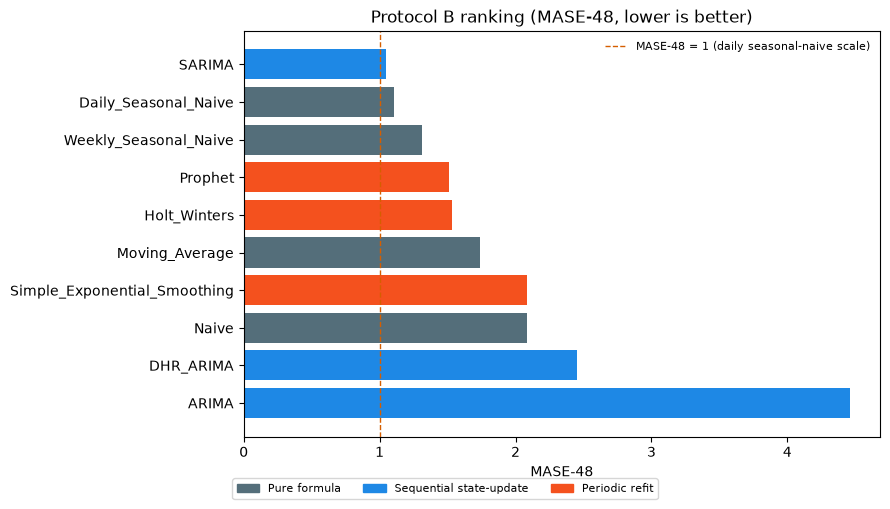

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors_b = [family_color[f] for f in comp_b.Family]
ax.barh(comp_b.Model[::-1], comp_b.MASE_48[::-1], color=bar_colors_b[::-1])
ax.axvline(1.0, color="#D55E00", linestyle="--", linewidth=1, label="MASE-48 = 1 (daily seasonal-naive scale)")
ax.set(title="Protocol B ranking (MASE-48, lower is better)", xlabel="MASE-48")
ax.legend(frameon=False, fontsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in family_color.values()]
ax.figure.legend(handles, family_color.keys(), loc="lower center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(); plt.show()

## 12.3 Relative Performance

In [67]:
best_deterministic_b = comp_b[comp_b.Family == "Pure formula"].iloc[0].Model
relative_b = comp_b[["Model", "MASE_48"]].copy()
relative_b["Relative to Naive"] = relative_b.MASE_48 / comp_b.set_index("Model").loc["Naive", "MASE_48"]
relative_b["Relative to Best Deterministic"] = relative_b.MASE_48 / comp_b.set_index("Model").loc[best_deterministic_b, "MASE_48"]
display(relative_b)
print(f"Best deterministic baseline under Protocol B: {best_deterministic_b}")

,Model,MASE_48,Relative to Naive,Relative to Best Deterministic
0,SARIMA,1.048901,0.503540,0.948740
1,Daily_Seasonal_Naive,1.105573,0.530746,1.000000
2,Weekly_Seasonal_Naive,1.308845,0.628330,1.183861
3,Prophet,1.513005,0.726339,1.368525
4,Holt_Winters,1.534479,0.736648,1.387948
5,Moving_Average,1.735886,0.833337,1.570123
6,Simple_Exponential_Smoothing,2.083055,1.000000,1.884140
7,Naive,2.083055,1.000000,1.884140
8,DHR_ARIMA,2.455674,1.178881,2.221177
9,ARIMA,4.459077,2.140643,4.033271


Best deterministic baseline under Protocol B: Daily_Seasonal_Naive


The ranking separation above already makes the Section 15 rank-reversal analysis visible
by inspection: several models occupy very different positions between Sections 11.1 and
12.1.

# 13. Protocol B Horizon-Specific Behaviour

Protocol B has 48 forecast horizons; this section synthesises horizon-specific evidence
across all ten models, derived only from the already-saved/already-computed frozen
forecasts above (`protocol_b_horizon_metrics.csv` for the four deterministic baselines,
`dhr_hmetrics` for DHR-ARIMA, and a direct groupby on each remaining model's already-loaded
Protocol B frame). No model is refit or re-evaluated beyond this horizon regrouping.

In [68]:
horizon_all = pd.concat([
    hmetrics[hmetrics.Model.isin(baseline_models)][["Model", "Horizon", "MAE", "RMSE", "MASE_48"]],
    dhr_hmetrics.assign(Model="DHR_ARIMA")[["Model", "Horizon", "MAE", "RMSE", "MASE_48"]],
    horizon_metrics_from_pb(arima_pb, test, "ARIMA", final_scale)[["Model", "Horizon", "MAE", "RMSE", "MASE_48"]],
    horizon_metrics_from_pb(sarima_pb, test, "SARIMA", final_scale)[["Model", "Horizon", "MAE", "RMSE", "MASE_48"]],
    horizon_metrics_from_pb(prophet_pb, test, "Prophet", final_scale)[["Model", "Horizon", "MAE", "RMSE", "MASE_48"]],
    horizon_metrics_from_pb(ses_pb, test, "Simple_Exponential_Smoothing", final_scale)[["Model", "Horizon", "MAE", "RMSE", "MASE_48"]],
    horizon_metrics_from_pb(hw_pb, test, "Holt_Winters", final_scale)[["Model", "Horizon", "MAE", "RMSE", "MASE_48"]],
], ignore_index=True)
assert horizon_all.groupby("Model").size().eq(48).all() and horizon_all.Model.nunique() == 10

## 13.1 RMSE by Horizon

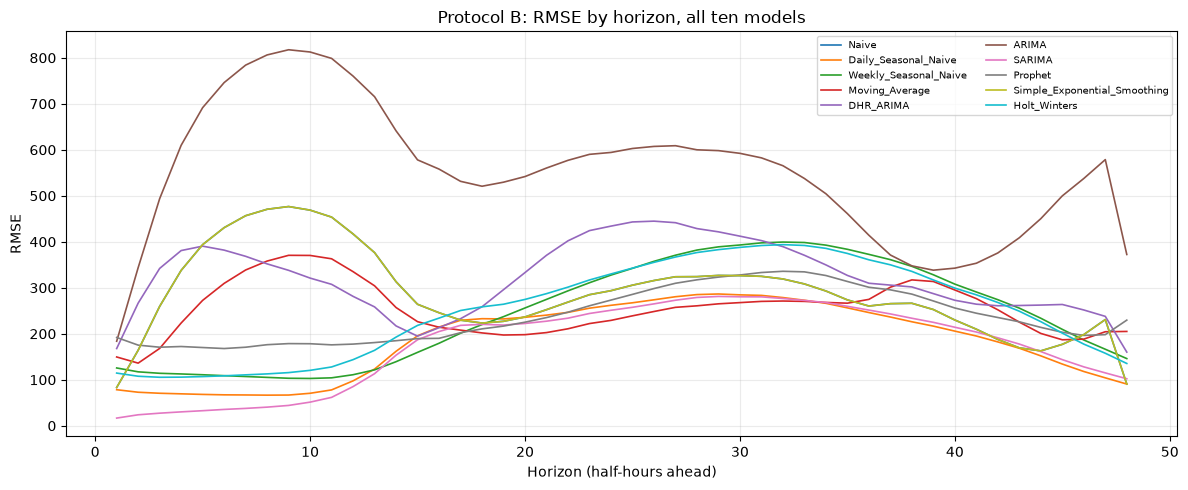

In [69]:
fig, ax = plt.subplots(figsize=(12, 5))
for m in all_models:
    g = horizon_all[horizon_all.Model == m]
    ax.plot(g.Horizon, g.RMSE, label=m, linewidth=1.2)
ax.set(title="Protocol B: RMSE by horizon, all ten models", xlabel="Horizon (half-hours ahead)", ylabel="RMSE")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 13.2 MASE-48 by Horizon

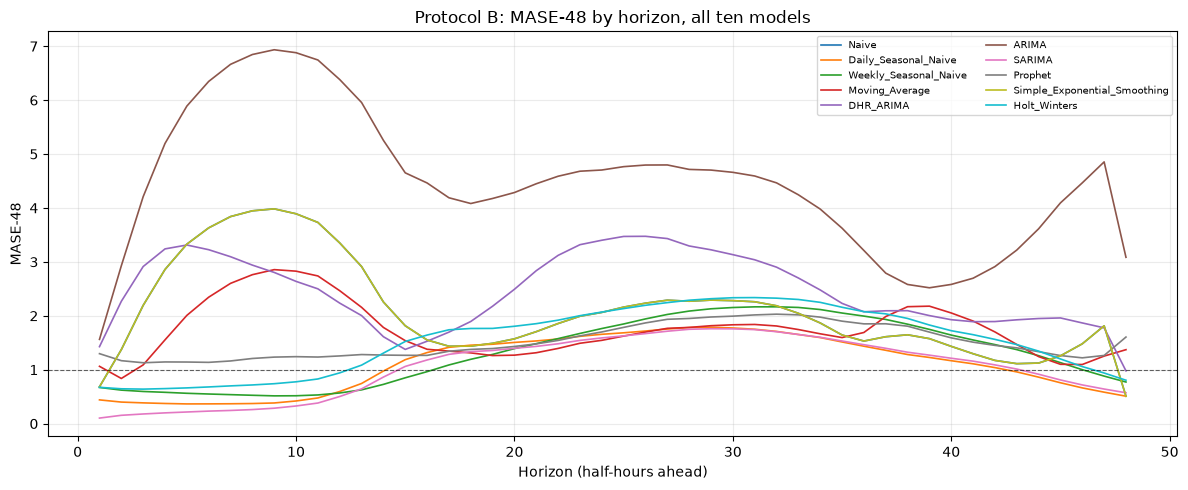

In [70]:
fig, ax = plt.subplots(figsize=(12, 5))
for m in all_models:
    g = horizon_all[horizon_all.Model == m]
    ax.plot(g.Horizon, g.MASE_48, label=m, linewidth=1.2)
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set(title="Protocol B: MASE-48 by horizon, all ten models", xlabel="Horizon (half-hours ahead)", ylabel="MASE-48")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 13.3 Early / Mid / Late Horizon Summary

`Degradation Ratio = RMSE(H25-H48) / RMSE(H1-H8)` — derived only from the frozen
horizon-specific evidence above.

In [71]:
def horizon_band_rmse(g, lo, hi):
    return g[(g.Horizon >= lo) & (g.Horizon <= hi)].RMSE.mean()

degradation_rows = []
for m in all_models:
    g = horizon_all[horizon_all.Model == m]
    early, mid, late = horizon_band_rmse(g, 1, 8), horizon_band_rmse(g, 9, 24), horizon_band_rmse(g, 25, 48)
    degradation_rows.append({"Model": m, "H1-H8 RMSE": early, "H9-H24 RMSE": mid, "H25-H48 RMSE": late, "Degradation Ratio": late / early})
degradation_table = pd.DataFrame(degradation_rows).sort_values("Degradation Ratio").reset_index(drop=True)
display(degradation_table)

,Model,H1-H8 RMSE,H9-H24 RMSE,H25-H48 RMSE,Degradation Ratio
0,Naive,324.579124,314.509059,255.962373,0.788598
1,Simple_Exponential_Smoothing,324.579121,314.509057,255.962372,0.788598
2,ARIMA,582.392529,632.963380,485.479199,0.833594
3,DHR_ARIMA,331.288877,305.193019,327.979422,0.990010
4,Moving_Average,244.516442,256.917988,255.271281,1.043984
5,Prophet,174.424956,207.940902,277.661427,1.591868
6,Weekly_Seasonal_Naive,112.710774,196.401345,320.250000,2.841343
7,Holt_Winters,109.035591,225.029934,313.048285,2.871065
8,Daily_Seasonal_Naive,70.029805,183.958449,221.321510,3.160390
9,SARIMA,30.572830,171.110885,224.311230,7.336947


Models with a degradation ratio near or below 1 hold their accuracy flat (or improve
slightly) across the day-ahead block; ratios well above 1 indicate accuracy concentrated
in the early horizon that erodes toward hour 24. The actual pattern is more nuanced than
"periodic-refit holds up, sequential-state degrades": Naive, Simple Exponential Smoothing,
ARIMA, and DHR-ARIMA all show ratios at or below 1 (0.79-0.99) -- these are exactly the
models whose Protocol A strength depends on the most-recently-observed actual (Section
15.2), so they start Protocol B already unable to exploit that advantage, and do not
degrade much further from there. **SARIMA -- the overall best model under both
protocols (Sections 11.1, 12.1) -- has by far the largest degradation ratio (approximately
7.3)**, but not because its late-horizon accuracy is poor: its H25-H48 RMSE (approximately
224) is close to Daily Seasonal Naive's (approximately 221), the strongest deterministic
baseline under Protocol B. The large ratio instead reflects an exceptionally low H1-H8
RMSE (approximately 31) that the model does not sustain through the full block -- SARIMA
reverts from exceptional to merely competitive, not from good to bad. Holt-Winters,
Weekly Seasonal Naive, and Daily Seasonal Naive also show substantial degradation
(ratios approximately 2.8-3.2). No statistical-significance claim is made about any of
these differences here (see `18_Electricity_Statistical_Significance.ipynb`).

# 14. Residual and Diagnostic Evidence

Purpose: show whether good aggregate metrics hide systematic error structure. Residuals
are defined consistently as `e_t = y_t - y_hat_t` (Actual minus Forecast), derived only
from the already-loaded frozen Protocol A forecasts above — no model is refit here. DHR's
Ljung-Box diagnostic is not repeated here because it already has its own specific
model-diagnostic treatment (Section 5.6).

In [72]:
residual_frames = {
    "Naive": pa_baseline.Naive, "Daily_Seasonal_Naive": pa_baseline.Daily_Seasonal_Naive,
    "Weekly_Seasonal_Naive": pa_baseline.Weekly_Seasonal_Naive, "Moving_Average": pa_baseline.Moving_Average,
    "DHR_ARIMA": pa_dhr.DHR_ARIMA, "ARIMA": arima_pa.ARIMA, "SARIMA": sarima_pa.SARIMA, "Prophet": prophet_pa.Prophet,
    "Simple_Exponential_Smoothing": ses_pa.Simple_Exponential_Smoothing, "Holt_Winters": hw_pa.Holt_Winters,
}
residual_summary_table = pd.DataFrame([residual_summary(test, residual_frames[m], m, "A") for m in all_models]).drop(columns="Protocol")
display(residual_summary_table)

,Model,Mean Residual,Std,Median,95th Abs Error,Max Abs Error
0,Naive,-0.005892,58.272152,-4.441481,113.433354,266.864326
1,Daily_Seasonal_Naive,-0.424835,200.441647,-1.531244,427.961605,1350.054906
2,Weekly_Seasonal_Naive,-0.927866,267.160071,-2.747576,583.169908,1764.434162
3,Moving_Average,-0.244184,227.658641,3.465548,453.380769,1044.732032
4,DHR_ARIMA,-3.340554,50.178243,-6.172449,84.178192,309.008052
5,ARIMA,-0.000910,51.681366,0.625920,87.338427,289.006430
6,SARIMA,-0.005361,25.350360,-0.100451,54.537139,239.255658
7,Prophet,2.022911,243.841167,-12.029186,470.914748,1589.360309
8,Simple_Exponential_Smoothing,-160.035209,255.734799,-165.267158,562.009381,1243.003809
9,Holt_Winters,13.566584,269.291124,-6.277635,575.339137,1761.279351


### Residual Bias Plot

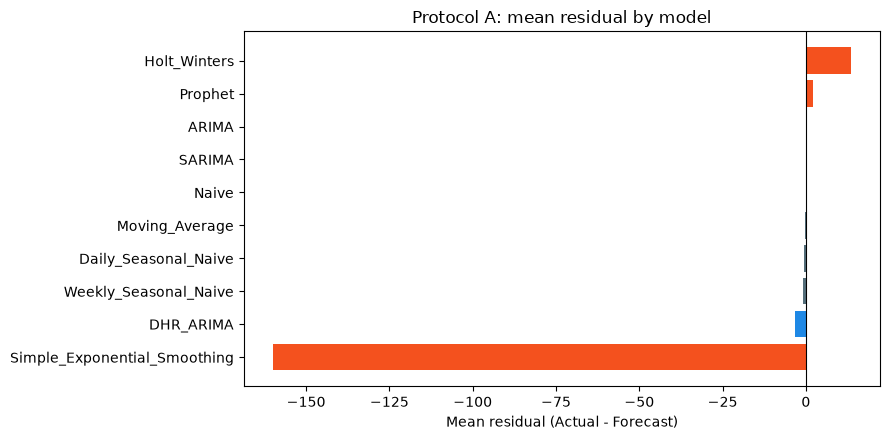

In [73]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = residual_summary_table.sort_values("Mean Residual").Model
colors_bias = [family_color[model_family[m]] for m in order]
ax.barh(order, residual_summary_table.set_index("Model").loc[order, "Mean Residual"], color=colors_bias)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Protocol A: mean residual by model", xlabel="Mean residual (Actual - Forecast)")
plt.tight_layout(); plt.show()

### Error Distribution Comparison

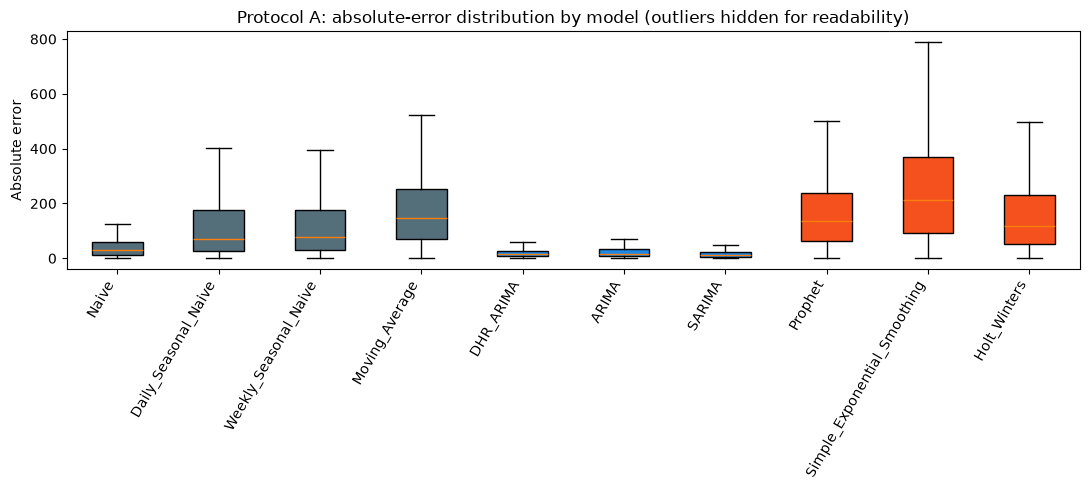

In [74]:
abs_errors = [np.abs(test.to_numpy() - residual_frames[m].to_numpy()) for m in all_models]
fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(abs_errors, tick_labels=all_models, showfliers=False, patch_artist=True)
for patch, m in zip(bp["boxes"], all_models):
    patch.set_facecolor(family_color[model_family[m]])
ax.set(title="Protocol A: absolute-error distribution by model (outliers hidden for readability)", ylabel="Absolute error")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()

No model's Protocol A residual mean is large relative to its own dispersion (Std column
above), so none shows a strong systematic bias at the aggregate level — differences
between models are dominated by dispersion (Std, 95th percentile absolute error), matching
the MASE-48 ranking in Section 11.1.

# 15. Protocol and Update-Discipline Analysis

## 15.1 Ranking Change Across Protocols

In [75]:
rank_a_map = comp_a.set_index("Model")["Rank"]
rank_b_map = comp_b.set_index("Model")["Rank"]
rank_change_table = pd.DataFrame({"Model": all_models})
rank_change_table["Protocol A Rank"] = rank_change_table.Model.map(rank_a_map)
rank_change_table["Protocol B Rank"] = rank_change_table.Model.map(rank_b_map)
rank_change_table["Rank Change"] = rank_change_table["Protocol B Rank"] - rank_change_table["Protocol A Rank"]
rank_change_table = rank_change_table.sort_values("Rank Change", key=np.abs, ascending=False).reset_index(drop=True)
display(rank_change_table)

,Model,Protocol A Rank,Protocol B Rank,Rank Change
0,DHR_ARIMA,2,9,7
1,ARIMA,3,10,7
2,Holt_Winters,9,5,-4
3,Naive,4,8,4
4,Daily_Seasonal_Naive,5,2,-3
5,Weekly_Seasonal_Naive,6,3,-3
6,Simple_Exponential_Smoothing,10,7,-3
7,Prophet,7,4,-3
8,Moving_Average,8,6,-2
9,SARIMA,1,1,0


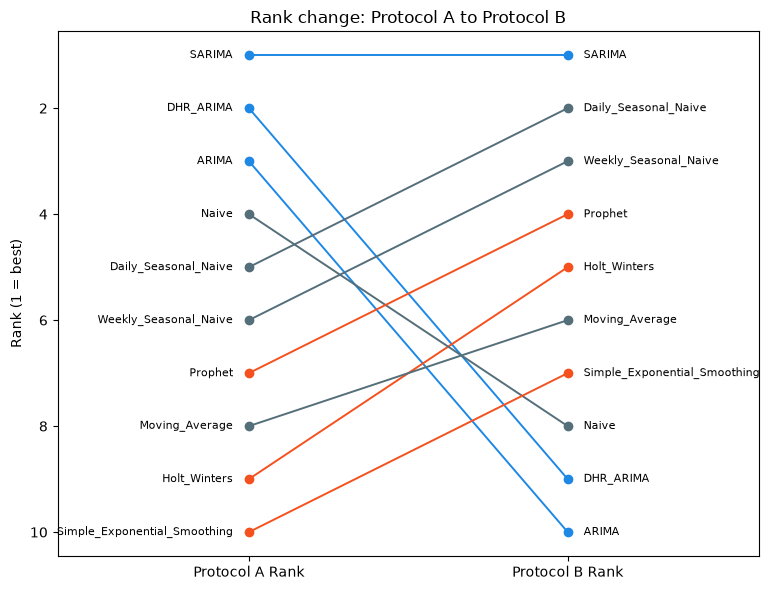

In [76]:
fig, ax = plt.subplots(figsize=(8, 6))
order = rank_change_table.Model.tolist()
for i, m in enumerate(order):
    a, b = rank_a_map[m], rank_b_map[m]
    ax.plot([0, 1], [a, b], color=family_color[model_family[m]], marker="o", linewidth=1.4)
    ax.text(-0.05, a, m, ha="right", va="center", fontsize=8)
    ax.text(1.05, b, m, ha="left", va="center", fontsize=8)
ax.set_xlim(-0.6, 1.6); ax.set_xticks([0, 1]); ax.set_xticklabels(["Protocol A Rank", "Protocol B Rank"])
ax.invert_yaxis(); ax.set(title="Rank change: Protocol A to Protocol B", ylabel="Rank (1 = best)")
plt.tight_layout(); plt.show()

## 15.2 Performance Change Across Protocols

In [77]:
performance_ratio_table = comp_a[["Model", "MASE_48"]].rename(columns={"MASE_48": "Protocol A MASE"}).merge(
    comp_b[["Model", "MASE_48"]].rename(columns={"MASE_48": "Protocol B MASE"}), on="Model")
performance_ratio_table["Ratio B/A"] = performance_ratio_table["Protocol B MASE"] / performance_ratio_table["Protocol A MASE"]
performance_ratio_table = performance_ratio_table.sort_values("Ratio B/A", ascending=False).reset_index(drop=True)
display(performance_ratio_table)

,Model,Protocol A MASE,Protocol B MASE,Ratio B/A
0,ARIMA,0.246727,4.459077,18.072936
1,DHR_ARIMA,0.227636,2.455674,10.787707
2,SARIMA,0.146347,1.048901,7.167198
3,Naive,0.361118,2.083055,5.768343
4,Moving_Average,1.530201,1.735886,1.134417
5,Daily_Seasonal_Naive,1.105573,1.105573,1.000000
6,Weekly_Seasonal_Naive,1.308845,1.308845,1.000000
7,Prophet,1.513005,1.513005,1.000000
8,Holt_Winters,1.534479,1.534479,1.000000
9,Simple_Exponential_Smoothing,2.083055,2.083055,1.000000


A large B/A ratio marks a model whose Protocol A accuracy relies heavily on information
that Protocol B withholds (the actual observed just before the forecast point); a ratio
near 1 marks a model whose accuracy is not sensitive to that information advantage. This
must be read carefully because the two protocols answer different operational questions
(Section 3.2-3.3) — a large ratio is not itself a flaw, it is evidence about *what kind of
information* a model's apparent accuracy depends on.

## 15.3 Update Discipline Summary

One row per model, populated incrementally as each model's configuration was derived in
Sections 4-10, rather than typed by hand.

In [78]:
update_summary = pd.DataFrame(model_run_log)
display(update_summary)

,Model,Discipline,Specification,Cadence_Days,Refits_During_Test,Runtime_Seconds
0,Naive,Pure formula,y_hat[t] = y[t-1],NaN,0,None
1,Daily_Seasonal_Naive,Pure formula,y_hat[t] = y[t-48],NaN,0,None
2,Weekly_Seasonal_Naive,Pure formula,y_hat[t] = y[t-336],NaN,0,None
3,Moving_Average,Pure formula,"Trailing mean, window=48",NaN,0,None
4,DHR_ARIMA,Sequential state-update,"Fourier daily_K=2, weekly_K=6; ARIMA(2, 0, 0) ...",NaN,0,None
5,ARIMA,Sequential state-update,"order=(2, 1, 0)",NaN,0,None
6,SARIMA,Sequential state-update,"seasonal_order=(0, 1, 0, 48)",NaN,0,None
7,Prophet,Periodic refit,native daily+weekly seasonality,14.0,69,None
8,Simple_Exponential_Smoothing,Periodic refit,single smoothing parameter,1.0,962,None
9,Holt_Winters,Periodic refit,damped additive trend + daily seasonal,14.0,69,None


Sequential state-update models (DHR-ARIMA, ARIMA, SARIMA) and, among the pure-formula
baselines, specifically **Naive** are the models most `consistent with` a large Protocol
A-to-B performance drop (Section 15.2, ratios 7.2-18.1) and Protocol A-favouring rank
shift (Section 15.1) -- all four rely on the most-recently-observed actual, which Protocol
B withholds. The other three pure-formula baselines (Daily Seasonal Naive, Weekly
Seasonal Naive, Moving Average) do **not** show this pattern (ratios 1.00-1.13, Section
15.2) despite also being "pure formula": their forecast rule is a fixed lag or window
rather than "the single most recent observation," so Protocol B does not remove any
information advantage they were exploiting under Protocol A. Periodic-refit models
(Prophet, Simple Exponential Smoothing, Holt-Winters) never receive a most-recent-actual
advantage in the first place, so their Protocol A and B behaviour is `consistent with`
being closer together (Prophet and Holt-Winters are numerically identical between
protocols by construction -- Section 8.3, 10.3; SES converges to the same result as Naive
under Protocol B specifically, Section 9.5, which is why it appears close to 1 in Section
15.2 despite being periodic-refit). No causal claim is made; these are associations
`consistent with` the update-discipline design, not proof that discipline alone
determines ranking.

# 16. Key Findings

### Protocol A
- Winner: **SARIMA** (MASE-48 approximately 0.146), the only model under approximately
  0.15 (Section 11.1).
- Runner-up: **DHR-ARIMA** (MASE-48 approximately 0.228), followed closely by **ARIMA**
  (approximately 0.247) -- all three sequential state-update models occupy the top three
  positions.
- Strongest deterministic baseline: **Naive** (MASE-48 approximately 0.361) -- stronger
  than every periodic-refit model and every other deterministic baseline under Protocol A
  (Section 4.1, 11.1).
- Strongest statistical model: **SARIMA** (also the overall winner).

### Protocol B
- Winner: **SARIMA** (MASE-48 approximately 1.049), still the best model, but by a much
  smaller margin over the field than under Protocol A (Section 12.1).
- Runner-up: **Daily Seasonal Naive** (MASE-48 approximately 1.106) -- a pure-formula
  baseline placing second overall once the one-step information advantage is removed.
- Strongest deterministic baseline: **Daily Seasonal Naive** -- the reverse of Protocol A,
  where Naive was strongest (Section 4.2, 12.1).
- Strongest statistical model: **SARIMA**.
- **DHR-ARIMA and ARIMA both collapse toward the bottom of the Protocol B ranking**
  (Section 12.1, 15.1) despite being the second- and third-best models under Protocol A --
  the largest rank reversals in the whole comparison, both +7 positions (Section 15.1).

### Horizon Behaviour
- Section 13.3's degradation ratios (`RMSE(H25-H48) / RMSE(H1-H8)`) show that **SARIMA --
  the overall Protocol B winner -- degrades the most across the day-ahead block**
  (ratio approximately 7.3), because its first-8-hour RMSE (approximately 31) is
  exceptionally low relative to its own later performance, not because its late-horizon
  RMSE (approximately 224) is unusually poor in absolute terms -- it remains close to
  Daily Seasonal Naive's (approximately 221) by hour 24 (Section 13.3).
- The four models whose Protocol A strength depends on the single most-recently-observed
  actual (Naive, Simple Exponential Smoothing, ARIMA, DHR-ARIMA) show the flattest
  degradation profiles (ratios 0.79-0.99, Section 13.3) -- they never had a
  horizon-dependent advantage to lose in the first place.
- Of the ten models, **Simple Exponential Smoothing and Naive are not actually distinct
  forecasting strategies under Protocol B** (Section 9.5): SES's selected smoothing
  parameter converges to alpha=1, making its Protocol B forecast vector numerically
  identical to Naive's (max absolute difference approximately 4e-6, floating-point
  optimizer noise) -- a nominal ten-model comparison should be read with this collapse in
  mind.

### Methodological Finding
> Model quality is protocol-dependent; a model's ranking cannot be interpreted
> independently of its information set, update discipline, seasonal capacity, and forecast
> horizon.

This is the central empirical result of this notebook: three of the top-four Protocol A
models (DHR-ARIMA, ARIMA, and to a lesser extent SARIMA) owe a substantial share of their
apparent strength to the one-step information advantage that only Protocol A grants
(Section 15.1-15.2), not to superior modelling of demand's underlying seasonal structure
per se -- and even SARIMA's Protocol B win is driven disproportionately by the first few
hours of each day-ahead block rather than uniformly strong 24-hour performance (Section
13.3).

# 17. Limitations

### Seasonal modelling asymmetry
DHR and Prophet can represent daily + weekly structure simultaneously; SARIMA and
Holt-Winters model only the daily period (48) as a stated computational fallback (Section
3.5) — this is not a fully controlled like-for-like comparison across the seven
model-based systems.

### Periodic-refit asymmetry
Prophet, Simple Exponential Smoothing, and Holt-Winters use validation-selected periodic
refits rather than the same sequential state-update mechanism as the DHR-ARIMA/ARIMA/SARIMA
family (Section 3.6) — the comparison is between complete forecasting systems, not
isolated model architectures.

### Frozen hyperparameters
All seven model-based selections (Sections 5-10) are validation-based but not exhaustive
searches; the underlying search spaces (Section 2.2) were fixed by the original workflow.

### DHR residual dependence
DHR-ARIMA's validation residuals fail the Ljung-Box white-noise test at lags 1, 48, and
336 in the historical run (Section 5.6) — its point forecasts should not be read as coming
from a fully specified error process.

### Protocol dependence
Protocol A and Protocol B answer different forecasting questions (Section 3.2-3.3); a
model's ranking under one protocol does not transfer to the other (Sections 11, 12, 15).

### Single region
Only South Australia (`T4`) half-hourly demand is evaluated here; no claim is made about
generalisation to other regions or frequencies (`10_Electricity_EDA.ipynb`, Section 20).

### Exogenous information
No weather, holiday, or price covariates are used by any model in this notebook — every
forecast is derived from the demand series alone.

### Statistical inference
This notebook reports descriptive model performance only. Formal significance testing
(Diebold-Mariano, effect sizes, multiple-comparison correction) belongs to
`18_Electricity_Statistical_Significance.ipynb`; no ranking difference in this notebook
should be read as statistically confirmed.

### DHR-ARIMA selection-evidence provenance
The DHR-ARIMA Fourier/ARIMA validation grid (Section 5.2), its final-fit coefficients
(5.3), and its Ljung-Box diagnostic (5.6) have no standalone machine-readable artifact
(Section 2.3), unlike ARIMA/SARIMA/Prophet/SES/Holt-Winters, which load live from
`classical_model_selection.json`. `RUN_SELECTION=True` independently reproduces the grid,
coefficients, and diagnostic from preserved development/validation data.

# 18. Next Notebook

Next: `12_Electricity_LSTM.ipynb`

Notebook 12 asks whether a supervised recurrent neural model can improve on the
transparent classical/statistical benchmark floor established here. The Protocol A and
Protocol B winners identified in Sections 11.1 and 12.1 — both **SARIMA** — together with
the strongest deterministic baselines (Naive under Protocol A, Daily Seasonal Naive under
Protocol B) remain the key reference points for that comparison and for the foundation
models evaluated in `13_Electricity_Foundation_Models.ipynb`.